<a href="https://colab.research.google.com/github/azambrano013/MLOpsAbr26/blob/main/entrenamiento_modelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## __Aprendizaje Supervisado__

__Profesor__: Rolando De LaCruz

__Ayudante__: Luis Oliveros

__Asunto__: Regresión Logística

__Evaluación__: Tarea 02

***

#Miembros del Equipo

Estudiantes: (Recordar colocar los RUTs, nombres y apellidos)

1. 14.129.637-K, Lorena Anavia Coihuin
3. 25.975.838-6, Alberto José Zambrano Paiva

# Este Trabajo se completó con la ayuda de Inteligencia Artificial - Gemini - Aprendizaje Guiado


Tarea 2

Desarrollo obligatorio en grupos de 2, 3 o 4 integrantes.

Fecha de entrega: hasta las 23.59 hrs del 02/12/25 vía webcursos. Sólo 1
integrante del grupo debe subir la tarea.

#DESCRIPCIÓN DEL PROBLEMA

Un vendedor de revistas está tratando de decidir qué revistas comercializar a los clientes.

En los "viejos tiempos", esto podría haber implicado tratar de decidir a qué clientes enviar anuncios a través del correo regular. En el contexto de hoy y de la "web", esto podría implicar decidir qué recomendaciones hacer a un cliente que ve una página web sobre otros artículos en los que el cliente podría estar interesado y por lo tanto querer comprar. Los dos problemas son esencialmente los mismos.

En este caso, el sitio web NoExisto.com (nombre ficticio) quiere decidir qué revistas incluir en los correos electrónicos a los clientes como parte de una campaña de comercialización por correo electrónico. Todos los e-mails que se enviarán irán a clientes que hayan comprado previamente una suscripción a la revista en NoExisto.com y que no hayan optado por no recibir e-mails.

Las revistas anunciadas en cada correo electrónico se seleccionarán automáticamente de forma específica para cada cliente cuando se genere el correo electrónico, a fin de maximizar la probabilidad de que el cliente compre. NoExisto.com solo incluirá anuncios de tres revistas en cada correo electrónico en una fila en la parte superior del mensaje porque la administración cree que incluir más anuncios es ineficaz. NoExisto.com también cree que incluir solo tres anuncios hace mucho más probable que los anuncios aparezcan en la vista previa del correo electrónico del destinatario y por lo tanto sean realmente vistos (sin que el destinatario tenga que abrir el correo electrónico).

Debido a que todos los destinatarios de los correos electrónicos han hecho previamente una compra en NoExisto.com, la compañía puede cotejar los datos recopilados cuando el cliente hizo su compra anterior con los datos de terceros (que pueden ser comprados en fuentes de datos como las agencias de calificación de crédito), por lo que tienen bastante información sobre cada cliente. Por ejemplo, tienen datos como los ingresos, el número de personas en el hogar, etc. Cada vez es más común este tipo de fusión de datos procedentes
de múltiples fuentes para reunir un "perfil" notablemente rico de cada cliente.

Aquí están las variables que NoExisto.com tiene sobre cada cliente de fuentes de terceros:

- Ingreso familiar (Income; redondeado a los $1,000.00 más cercanos)
- Sexo (IsFemale = 1 si la persona es mujer, 0 en caso contrario)
- Estado civil (IsMarried = 1 si está casado, 0 en caso contrario)
- Educado en la universidad (HasCollege = 1 si tiene uno o más años de educación
universitaria, 0 en caso contrario)
- Empleado en una profesión (IsProfessional = 1 si está empleado en una profesión, 0
en caso contrario)
- Jubilado (IsRetired = 1 si está jubilado, 0 en caso contrario)
- No empleado (Unemployed = 1 si no está empleado, 0 en caso contrario)
- Duración de la residencia en la ciudad actual (ResLength; en años)
- Doble Ingreso si está casado (Dual = 1 si es doble ingreso, 0 en caso contrario)
- Niños (Minors = 1 si hay niños menores de 18 años en el hogar, 0 en caso contrario)
- Propiedad de la vivienda (Own = 1 si es residencia propia, 0 en caso contrario)
- Tipo de residente (House = 1 si la residencia es una casa unifamiliar, 0 en caso contrario)
- Raza (White = 1 si la raza es blanca, 0 en caso contrario)
- Idioma (English = 1 es el idioma principal en el hogar es el Inglés, 0 de lo contrario)

**¿Cómo puede NoExisto.com decidir qué revistas comercializar para cada persona, es decir, qué anuncios poner en cada e-mail? Una forma sería desarrollar una ecuación (aquí es donde entra en juego la regresión logística multivariante) que prediga la probabilidad de que un cliente compre una revista en particular basándose en los datos que la compañía tiene sobre el cliente. Tal ecuación se desarrollaría para cada revista que la compañía vende.**

Si NoExisto.com tiene un modelo de este tipo para cada revista que vende, puede calcular la probabilidad de que el cliente compre para cada una de las revistas que ofrece. Luego pueden poner las tres revistas principales en el correo electrónico (es decir, las tres que el modelo predice que el cliente tiene más probabilidades de comprar).

Nota: NoExisto.com puede hacer cosas más complicadas que sólo mirar las probabilidades predichas (como mirar la ganancia esperada de la venta), pero para simplificar, supongamos que el objetivo es poner anuncios en el correo electrónico para las tres revistas que el cliente tiene más probabilidades de comprar.

Para poder desarrollar una ecuación que prediga la probabilidad de que un cliente compre una revista en particular, la empresa deberá realizar un experimento para recoger datos sobre el comportamiento de compra del cliente. Una forma de hacerlo es seleccionar al azar algunos clientes de la base de datos de clientes y luego enviarles correos electrónicos con anuncios seleccionados al azar. El hecho de que estos clientes compren o no las revistas
anunciadas puede proporcionar los datos necesarios para estimar las ecuaciones que se utilizarán para predecir la probabilidad de que un cliente compre una revista en particular.

Si se dispone de un gran número de revistas que se venden, puede ser necesario enviar un  un gran número de correos electrónicos para obtener ecuaciones de predicción útiles.

Asegurarse de que se dispone de suficientes datos para que cada revista termine con una ecuación útil para predecir la probabilidad de compra puede ser un poco complicado (y requiere un gran número de correos electrónicos en el experimento), pero no se abordarán estos temas en este caso.

Así pues, el problema de decidir qué anuncios de revista colocar en cada correo electrónico se reduce a desarrollar una ecuación para cada revista que prediga la probabilidad de que un cliente compre. Vamos a centrarnos ahora en la cuestión de desarrollar dicha ecuación para una revista ("Niños Creativos") cuyo público objetivo son los niños de entre 9 y 12 años.

En el proceso de envío de los e-mails "experimentales", el anuncio de " Niños Creativos" fue mostrado en 673 e-mails a los clientes y se registró el comportamiento de compra.

Además de las variables para cada cliente enumeradas anteriormente (las obtenidas de fuentes de terceros), NoExisto.com tiene las siguientes variables de sus propias bases de datos:

- Previamente compró una revista para padres (PrevParent = 1 si previamente
compró una revista para padres, 0 en caso contrario).
- Previamente compró una revista infantil (PrevChild = 1 si previamente compró una revista infantil, 0 en caso contrario).

La variable dependiente "Y" proviene del "experimento", es decir, de los 673 correos electrónicos a los clientes que contienen el anuncio de "Niños Creativos" y si el cliente compró o no la revista. Es decir, la variable dependiente es:

- Compró "Niños Creativos" (Buy = 1 si compró "Niños Creativos", 0 en caso contrario)

El archivo “NiniosCreativos.csv” contiene la data descrita.

a) Divida la data en una muestra de entrenamiento (80%) y una muestra de validación (20%). Realice un análisis exploratorio de los datos que revelen cosas de interés para lograr el desarrollo del modelo de regresión logística.

b) Ajuste un modelo de regresión logística multivariado usando la data de
entrenamiento considerando todas los atributos para predecir P(Buy=1|atributos). Comente resultados que sean interesantes destacar.

c) Usando técnicas de selección de variables encuentre un modelo más reducido.
Comente los resultados.  

d) Verifique si los atributos seleccionados en el modelo de la parte c) son significativos o no. Comente sus resultados.

e) Usando el modelo seleccionado en la parte d) calcule métricas de calidad predictiva (AUC, K-S, Sensibilidad, Especificidad, etc.) en la muestra de entrenamiento y en la muestra de validación. Comente y compare resultados.

f) Haga un gráfico de las curvas ROC para la muestras de entrenamiento y de
validación. Comente resultados.

g) Ahora ajuste una regresión logística con regularización (ridge, lasso, elestic net) a los datos de entrenamiento. Calcule métricas de calidad predictiva (AUC, K-S, Sensibilidad, Especificidad, etc.) en la muestra de entrenamiento y en la muestra de validación. Comente y compare los resultados obtenidos con los obtenidos en la parte e).

h) De todos los modelos considerados, ¿Cuál es el mejor? ¿Por qué?

i) Discuta cómo usaría el modelo para cumplir los objetivos de NoExisto.com.

Subir a la plataforma un Notebook de Python (en Colab) con la solución de la tarea. Al momento de seleccionar las muestras de entrenamiento y testing use una semilla (con la función apropiada en Python) y deje la semilla utilizada en su Notebook.




---



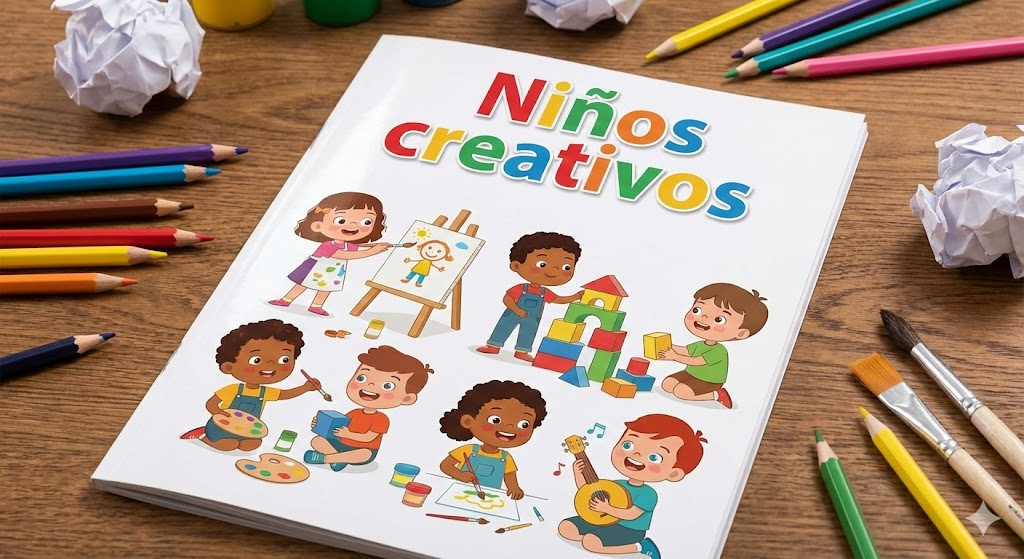

#i.Resumen Ejecutivo

**Problema:** NoExisto.com busca predecir la probabilidad de compra de la revista "Niños Creativos" para optimizar campañas de marketing personalizadas.

**Metodología:**
1.  **Datos:** Se preprocesó `NiniosCreativos.csv` (673 registros), manejando el desbalance de clases y estandarizando variables.
2.  **Modelos:** Se exploraron Naive Bayes, Regresión Logística (completa y reducida por Backward Elimination), y Regresión Logística con regularización (Lasso y ElasticNet).
3.  **Criterios de Selección:** Se priorizó la parsimonia (menor # variables) y el rendimiento en validación (Val AUC, Val K-S, Sensibilidad, Especificidad).

**Resultados y Modelo Ganador:**
El **Modelo de Regresión Logística con Regularización ElasticNet** fue el ganador. Logró un rendimiento excepcional con solo **7 variables**, demostrando robustez y excelente generalización. Sus métricas clave en validación fueron: `Val AUC` de **0.9755**, `Val K-S` de **0.8145**, `Sensibilidad` de **0.80** y `Especificidad` de **0.9818**.

**Tabla Comparativa (Validación):**
| Modelo                      | # Var. | Val AUC | Val K-S | Val Sens. | Val Spec. |
| :-------------------------- | :----- | :------ | :------ | :-------- | :-------- |
| ElasticNet Logistic Reg.    | 7      | 0.9755  | 0.8145  | 0.80      | 0.9818    |
| Lasso Logistic Regression   | 7      | 0.9704  | 0.8055  | 0.80      | 0.9727    |
| Reduced Logistic Regression | 7      | 0.9649  | 0.7891  | 0.76      | 0.9727    |
| Full Logistic Regression    | 16     | 0.9775  | 0.8327  | 0.80      | 0.9818    |
| Naive Bayes                 | 16     | 0.7862  | 0.6291  | 0.64      | 0.9091    |

**Fórmula del Modelo Ganador (Coeficientes Desestandarizados):**
`log(p / (1-p)) = -12.2996 + (0.0001480 * Income) + (1.1578 * IsFemale) - (1.8450 * IsRetired) + (0.7582 * Minors) + (1.0730 * Own) + (1.4605 * PrevChild) + (1.6926 * White)`
Donde `p` es la probabilidad de compra. `p = 1 / (1 + exp(-log(p / (1-p))))`.

**Uso en Marketing:**
NoExisto.com usará esta fórmula para calcular probabilidades de compra, personalizar emails y maximizar la conversión, optimizando el gasto y la experiencia del cliente.


---




#RESOLUCIÓN

##Link de Github en repositorio donde está el dataset en su estado puro

In [1]:
#Para identificar el link de GitHub donde está el dataset raw
github_data_raw = "https://raw.githubusercontent.com/azambrano013/ML_Superv_ClassificationNov25/refs/heads/main/NiniosCreativos.csv"

## Para definir la semilla 9001 a utilizar en el cuaderno


In [2]:
# Para definir la semilla a utilizar en el cuaderno
SEED_RANDOM_STATE=9001

#0.Configuración Inicial y Reproducibilidad


##0.1. Importar librerías

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm


##0.2. Cargar el dataset "NiniosCreativos.csv" desde el Github

In [4]:
df_raw = pd.read_csv(github_data_raw)
print("Dataset cargado exitosamente. Las primeras 5 filas son:")
print(df_raw.head())

Dataset cargado exitosamente. Las primeras 5 filas son:
   ObsNo.  Buy  Income  IsFemale  IsMarried  HasCollege  IsProfessional  \
0       1    0   24000         1          0           1               1   
1       2    1   75000         1          1           1               1   
2       3    0   46000         1          1           0               0   
3       4    1   70000         0          1           0               1   
4       5    0   43000         1          0           0               0   

   IsRetired  Unemployed  ResLength  Dual  Minors  Own  House  White  English  \
0          0           0         26     0       0    0      1      0        0   
1          0           0         15     1       0    1      1      1        1   
2          0           0         36     1       1    1      1      1        1   
3          0           0         55     0       0    1      1      1        1   
4          0           0         27     0       0    0      0      1        1   

   Pre

##0.3.1. Info y describe de df_raw

In [5]:
print("Información general del DataFrame (df_raw.info()):")
df_raw.info()

Información general del DataFrame (df_raw.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 673 entries, 0 to 672
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ObsNo.          673 non-null    int64
 1   Buy             673 non-null    int64
 2   Income          673 non-null    int64
 3   IsFemale        673 non-null    int64
 4   IsMarried       673 non-null    int64
 5   HasCollege      673 non-null    int64
 6   IsProfessional  673 non-null    int64
 7   IsRetired       673 non-null    int64
 8   Unemployed      673 non-null    int64
 9   ResLength       673 non-null    int64
 10  Dual            673 non-null    int64
 11  Minors          673 non-null    int64
 12  Own             673 non-null    int64
 13  House           673 non-null    int64
 14  White           673 non-null    int64
 15  English         673 non-null    int64
 16  PrevChild       673 non-null    int64
 17  PrevParent      673 no

#100.Preprocesamiento y Análisis Exploratorio (Rúbrica: a)
**Objetivo:** Comprender los datos y preparar los conjuntos de entrenamiento y validación.
**Tareas:**
1. **División de Datos:** Separar el dataset en Entrenamiento (80%) y Validación (20%) y definir usando la semilla definida.
2. **Análisis Exploratorio (EDA):**
* Verificar tipos de datos y valores nulos.
* Analizar el balance de la variable objetivo (`Buy`).
* Analizar la existencia de outliers y tomar una decisión acerca de su tratamiento. * Visualizar correlaciones y relaciones clave entre variables demográficas y la decisión de compra.
* *Entregable:* Fundamentar visualmente la capacidad de la data para predecir.

###110.Análisis de datos duplicados



In [6]:
print("Revisando duplicados en el dataset...")
duplicates = df_raw.duplicated().sum()

if duplicates > 0:
    print(f"Se encontraron {duplicates} filas duplicadas.")
    df_clean = df_raw.drop_duplicates().copy()
    print("Duplicados eliminados. El nuevo DataFrame 'df_clean' tiene las siguientes dimensiones:")
    print(df_clean.shape)
else:
    print("No se encontraron filas duplicadas.")
    df_clean = df_raw.copy()
    print("El DataFrame 'df_clean' es una copia de 'df_raw' y tiene las siguientes dimensiones:")
    print(df_clean.shape)


Revisando duplicados en el dataset...
No se encontraron filas duplicadas.
El DataFrame 'df_clean' es una copia de 'df_raw' y tiene las siguientes dimensiones:
(673, 18)


Análisis de duplicados: no hay datos duplicados en el dataset df_raw y hemos creado el dataset 'df_clean' para diferenciarlos.

###111.Identificación de valores ausentes.

In [7]:
# Separar columnas especiales (identificador y variable objetivo)
special_cols = ['ObsNo.', 'Buy']

# Identificar columnas de características
feature_cols = [col for col in df_clean.columns if col not in special_cols]

# Identificar columnas numéricas (continuas)
numerical_features = ['Income', 'ResLength']

# Identificar columnas categóricas (binarias en este caso)
categorical_features = [col for col in feature_cols if col not in numerical_features]

# Ordenar alfabéticamente dentro de cada grupo
sorted_numerical_features = sorted(numerical_features)
sorted_categorical_features = sorted(categorical_features)

# Construir el nuevo orden de columnas
new_column_order = ['ObsNo.'] + sorted_numerical_features + sorted_categorical_features + ['Buy']

# Aplicar el nuevo orden al DataFrame
df_clean = df_clean[new_column_order]

print("Columnas del DataFrame df_clean reordenadas:")
print(df_clean.head())
print("\nInformación del DataFrame df_clean con las columnas reordenadas:")
df_clean.info()


Columnas del DataFrame df_clean reordenadas:
   ObsNo.  Income  ResLength  Dual  English  HasCollege  House  IsFemale  \
0       1   24000         26     0        0           1      1         1   
1       2   75000         15     1        1           1      1         1   
2       3   46000         36     1        1           0      1         1   
3       4   70000         55     0        1           0      1         0   
4       5   43000         27     0        1           0      0         1   

   IsMarried  IsProfessional  IsRetired  Minors  Own  PrevChild  PrevParent  \
0          0               1          0       0    0          0           0   
1          1               1          0       0    1          1           0   
2          1               0          0       1    1          0           0   
3          1               1          0       0    1          1           0   
4          0               0          0       0    0          0           1   

   Unemployed  White  B

In [8]:
print("Estadísticas generales del DataFrame df:")
df_clean.describe()


Estadísticas generales del DataFrame df:


,ObsNo.,Income,ResLength,Dual,English,HasCollege,House,IsFemale,IsMarried,IsProfessional,IsRetired,Minors,Own,PrevChild,PrevParent,Unemployed,White,Buy
count,673.00000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000
mean,337.00000,35078.751857,17.618128,0.231798,0.909361,0.289747,0.667162,0.551263,0.349183,0.341753,0.057949,0.364042,0.362556,0.071322,0.084695,0.031204,0.692422,0.185736
std,194.42265,23812.787498,13.555818,0.422294,0.287308,0.453982,0.471580,0.497735,0.477066,0.474650,0.233822,0.481518,0.481096,0.257554,0.278635,0.173997,0.461834,0.389182
min,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,169.00000,14000.000000,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,337.00000,32000.000000,16.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,505.00000,52000.000000,24.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,673.00000,75000.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Las conclusiones más importantes del df_clean.describe() son:

1. Desbalance de Clases en la Variable Objetivo (Buy): Solo un 18.57% de los clientes compraron la revista 'Niños Creativos'. Este desbalance significativo es crucial y deberá ser considerado en el modelado.
2. Ausencia de Valores Nulos: Todas las columnas tienen 673 entradas no nulas, lo que indica que el dataset está completo y no requiere manejo de valores faltantes.
3. El tipo de datos de los atributos es adecuado.

**Características Numéricas Clave:**
- Income (Ingresos): Varía entre 0 y 75,000, con una media de 35,078.75, mostrando una amplia distribución de ingresos.
- ResLength (Duración de Residencia): Va de 0 a 72 años, con una media de 17.61 años, lo que sugiere una población con diferentes grados de estabilidad en su residencia.

**Distribución de Variables Binarias:**
Las medias de las variables binarias (0/1) representan la proporción de la característica:
- IsFemale: El 55.13% de los clientes son mujeres.
- IsMarried: El 34.92% están casados.
- Minors: El 36.40% de los hogares tienen menores.
- PrevChild (7.13%) y PrevParent (8.47%): Un bajo porcentaje de clientes ha comprado previamente revistas infantiles o para padres, lo que podría indicar que estas características son buenos predictores para el pequeño grupo que sí compra.

###112.Separación del dataset 'df_clean' en 80% Train y 20% Test

In [9]:
# Separar la variable objetivo (y) de las variables predictoras (X) y eliminación del atributo ObsNo.
X = df_clean.drop(['ObsNo.', 'Buy'], axis=1)
y = df_clean['Buy']

# Dividir el dataset en conjuntos de entrenamiento y validación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED_RANDOM_STATE, stratify=y)

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

print("\nBalance de la variable 'Buy' en el conjunto de entrenamiento:")
print(y_train.value_counts(normalize=True))
print("\nBalance de la variable 'Buy' en el conjunto de validación:")
print(y_test.value_counts(normalize=True))

Dimensiones de X_train: (538, 16)
Dimensiones de X_test: (135, 16)
Dimensiones de y_train: (538,)
Dimensiones de y_test: (135,)

Balance de la variable 'Buy' en el conjunto de entrenamiento:
Buy
0    0.814126
1    0.185874
Name: proportion, dtype: float64

Balance de la variable 'Buy' en el conjunto de validación:
Buy
0    0.814815
1    0.185185
Name: proportion, dtype: float64


###113.Visualización de variables de Train y Test para analizar desbalanceo de clases

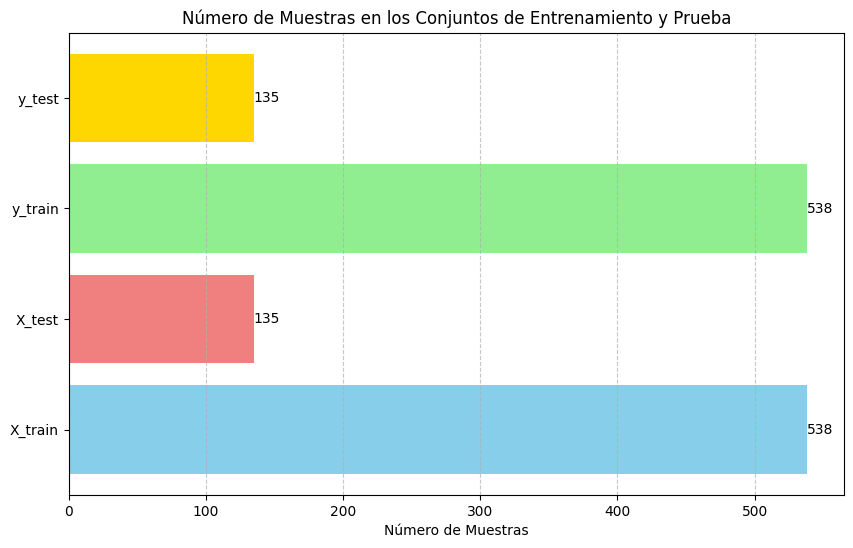

In [10]:
# Separar la variable objetivo (y) de las variables predictoras (X) y eliminación del atributo ObsNo por ser solo un identificador.
X = df_clean.drop(['ObsNo.', 'Buy'], axis=1)
y = df_clean['Buy']

# Dividir el dataset en conjuntos de entrenamiento y validación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED_RANDOM_STATE, stratify=y)

data_sizes = {
    'X_train': X_train.shape[0],
    'X_test': X_test.shape[0],
    'y_train': y_train.shape[0],
    'y_test': y_test.shape[0]
}

labels = list(data_sizes.keys())
values = list(data_sizes.values())

plt.figure(figsize=(10, 6))
bars = plt.barh(labels, values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.xlabel('Número de Muestras')
plt.title('Número de Muestras en los Conjuntos de Entrenamiento y Prueba')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Añadir etiquetas a las barras
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{int(width)}', va='center', ha='left', fontsize=10, color='black')

plt.show()

Ahora que hemos separado el dataset, podemos comenzar a analizar el dataset de entrenamiento para el desarrollo del modelo.


###114.Info y describe de X_train

In [11]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 538 entries, 500 to 292
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Income          538 non-null    int64
 1   ResLength       538 non-null    int64
 2   Dual            538 non-null    int64
 3   English         538 non-null    int64
 4   HasCollege      538 non-null    int64
 5   House           538 non-null    int64
 6   IsFemale        538 non-null    int64
 7   IsMarried       538 non-null    int64
 8   IsProfessional  538 non-null    int64
 9   IsRetired       538 non-null    int64
 10  Minors          538 non-null    int64
 11  Own             538 non-null    int64
 12  PrevChild       538 non-null    int64
 13  PrevParent      538 non-null    int64
 14  Unemployed      538 non-null    int64
 15  White           538 non-null    int64
dtypes: int64(16)
memory usage: 71.5 KB


In [12]:
X_train.describe()

,Income,ResLength,Dual,English,HasCollege,House,IsFemale,IsMarried,IsProfessional,IsRetired,Minors,Own,PrevChild,PrevParent,Unemployed,White
count,538.000000,538.000000,538.000000,538.000000,538.000000,538.000000,538.000000,538.000000,538.000000,538.000000,538.000000,538.000000,538.000000,538.000000,538.000000,538.000000
mean,35213.754647,17.276952,0.239777,0.905204,0.308550,0.669145,0.539033,0.351301,0.368030,0.053903,0.358736,0.362454,0.079926,0.091078,0.031599,0.700743
std,23819.558268,13.218810,0.427345,0.293205,0.462325,0.470959,0.498938,0.477821,0.482718,0.226037,0.480076,0.481156,0.271430,0.287988,0.175091,0.458359
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14250.000000,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,33000.000000,15.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,54000.000000,24.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,75000.000000,68.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Estos análisis solo nos confirman que se mantienen para X_Train las mismas conclusiones que ya habiamos sacado para el dataset completo anteriormente.

##120.Descripción de atributos y análisis de outliers

Generando pairplot de X_train. Esto puede tomar un momento y generar una imagen grande debido al número de variables.


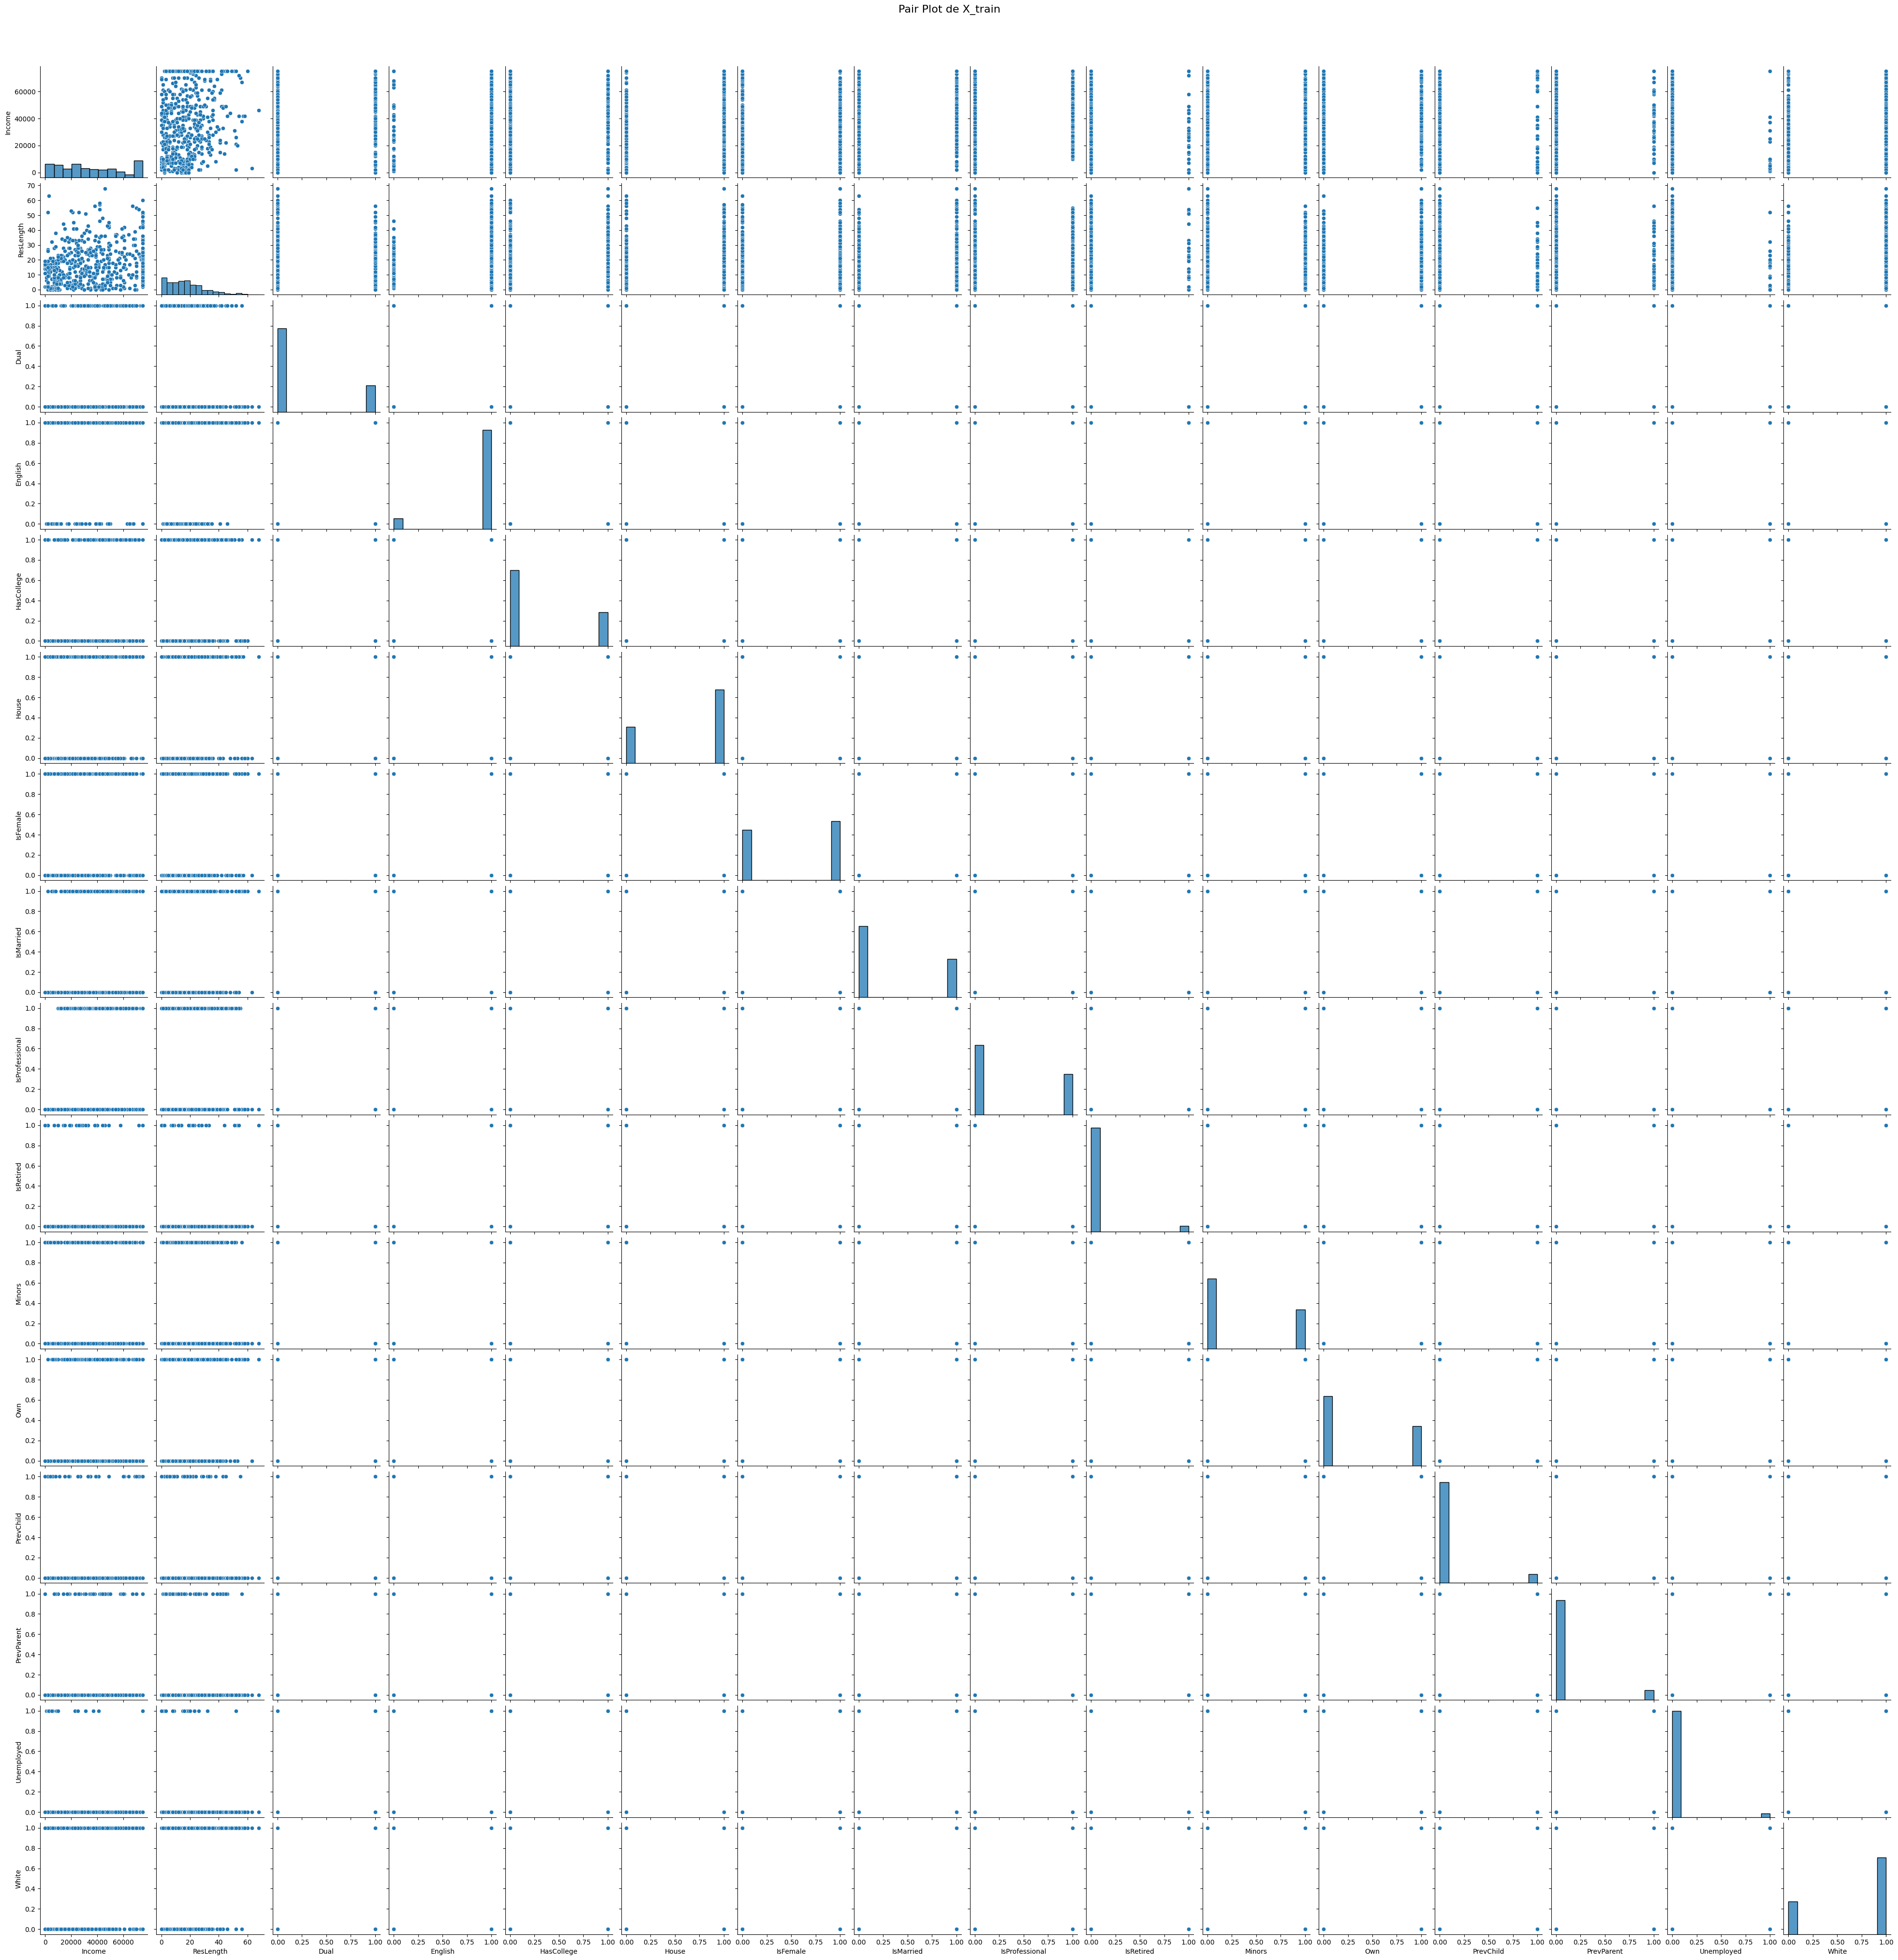

In [13]:
# Generar el pairplot de X_train
print("Generando pairplot de X_train. Esto puede tomar un momento y generar una imagen grande debido al número de variables.")
sns.pairplot(X_train)
plt.suptitle('Pair Plot de X_train', y=1.02, fontsize=16) # Añadir un título general
plt.show()

**Distribución de Variables Numéricas:** Los histogramas en la diagonal (para Income y ResLength) muestran la distribución individual de cada variable. Se puede ver que ambas tienen distribuciones sesgadas, con Income mostrando una concentración en los valores más bajos y ResLength también con una distribución no normal con varias modas.

**Relaciones entre Variables Numéricas:** Los diagramas de dispersión entre Income y ResLength (fuera de la diagonal) revelan si existe alguna tendencia o correlación entre estas dos variables. A primera vista, no parece haber una correlación lineal muy fuerte, pero podría haber patrones no lineales o clústeres.

**Relación de Numéricas con Binarias:** Al observar los gráficos de dispersión donde una variable numérica se cruza con una binaria (0 o 1), se puede tener una idea visual de cómo se distribuye la variable numérica en cada categoría de la binaria. Por ejemplo, cómo se distribuyen los ingresos para IsFemale=0 vs IsFemale=1, o HasCollege=0 vs HasCollege=1.

**Correlaciones y Ausencia de Correlaciones Evidentes: **Aunque el pair plot no da valores exactos de correlación (para eso se usa el heatmap), permite identificar rápidamente si hay relaciones lineales obvias. Para la mayoría de las variables binarias, no se esperan correlaciones lineales fuertes entre ellas o con las numéricas, sino más bien cómo se agrupan los puntos.

## 121.Visualización del Triángulo Superior de la Matriz de Correlación

Para una visualización más limpia y centrada en las relaciones positivas, mostramos solo el triángulo superior de la matriz de correlación, utilizando una escala de colores de amarillo a rojo.

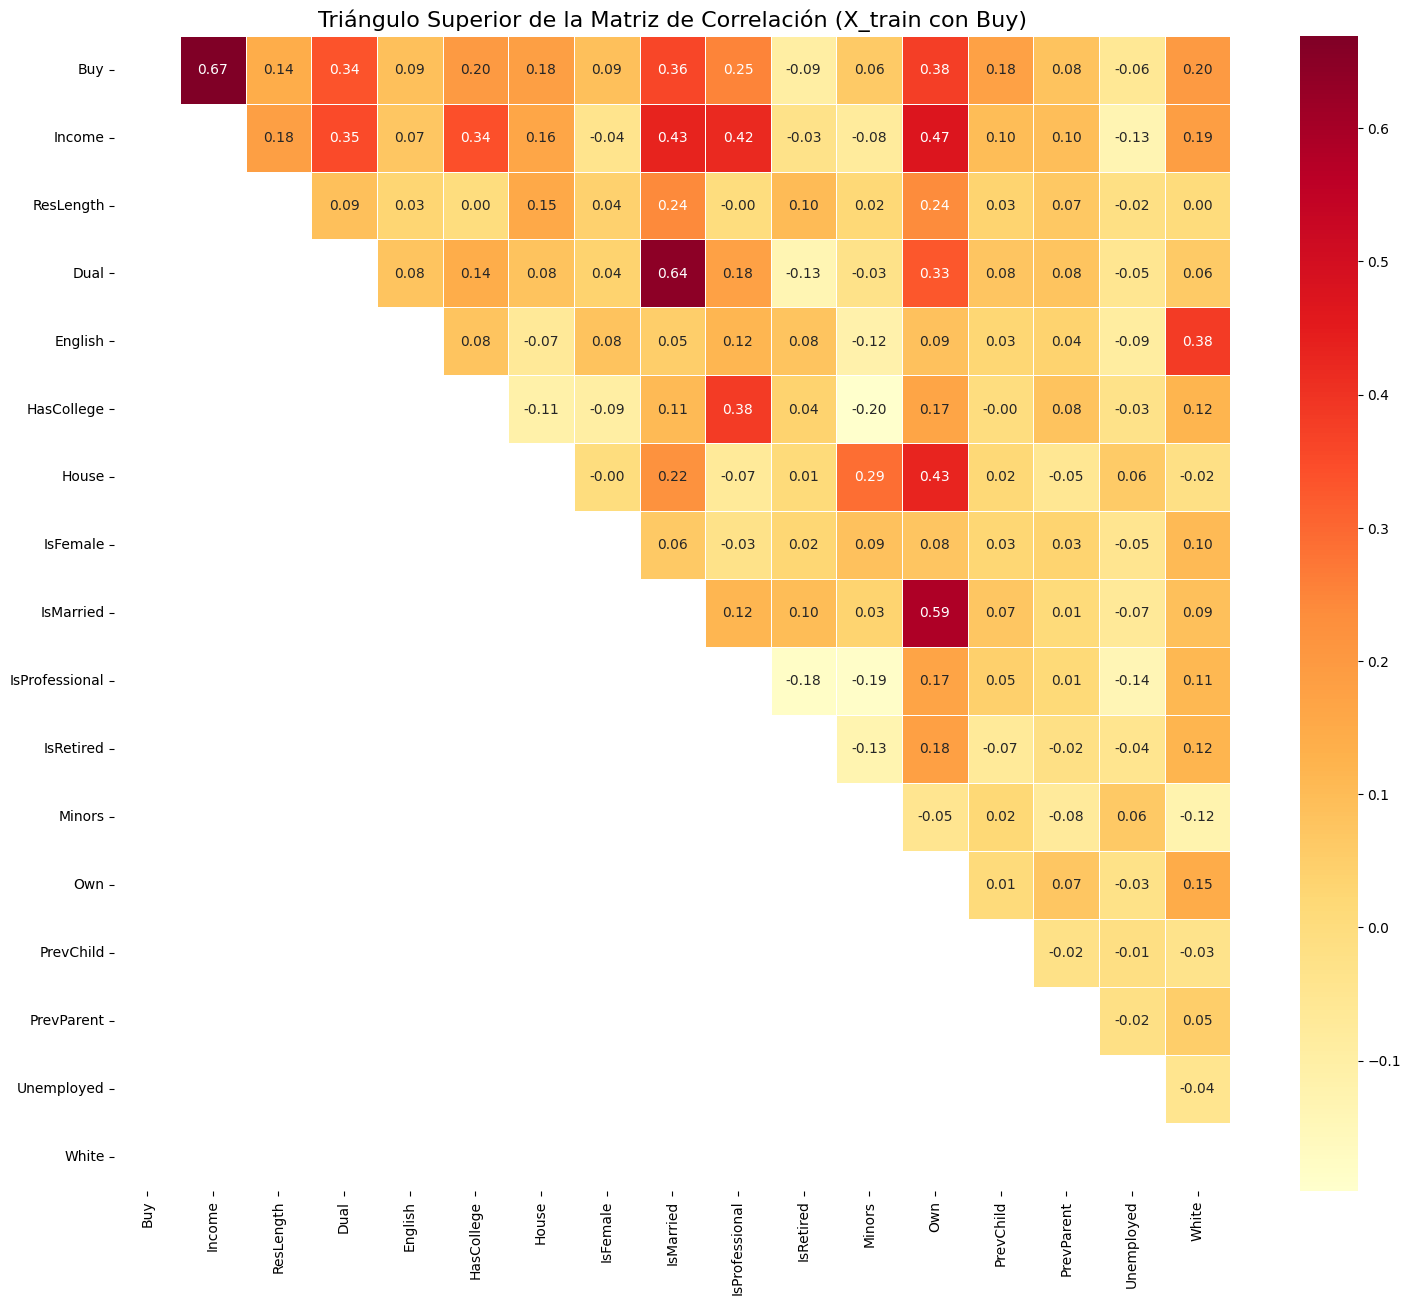

In [14]:
# Combinar X_train y y_train para calcular la correlación con la variable objetivo 'Buy'
df_train_combined = pd.concat([X_train, y_train], axis=1)

# Calcular la matriz de correlación
correlation_matrix = df_train_combined.corr()

# Reordenar las columnas y filas para que 'Buy' sea la primera
ordered_cols = ['Buy'] + [col for col in correlation_matrix.columns if col != 'Buy']
correlation_matrix = correlation_matrix.loc[ordered_cols, ordered_cols]

# Crear una máscara para el triángulo inferior, para que el heatmap muestre el superior
mask = np.tril(np.ones_like(correlation_matrix, dtype=bool))

# Visualizar la matriz de correlación con un heatmap, mostrando solo el triángulo superior
plt.figure(figsize=(18, 15)) # Aumentar el tamaño para acomodar la nueva variable
sns.heatmap(correlation_matrix, annot=True, cmap='YlOrRd', fmt=".2f", linewidths=.5, mask=mask)
plt.title('Triángulo Superior de la Matriz de Correlación (X_train con Buy)', fontsize=16)
plt.show()



**¿Cuáles fueron los hallazgos con respecto a la colinealidad entre las variables independientes?**
El análisis de las variables independientes en X_train no reveló pares con un coeficiente de correlación absoluto superior a 0.7. Esto indica una ausencia de multicolinealidad significativa en este umbral.

**¿Cuáles son las acciones recomendadas para la fase de desarrollo del modelo dados estos hallazgos?** Dado que no se detectó una alta colinealidad, no hay una necesidad inmediata de aplicar técnicas específicas para manejar la multicolinealidad, como eliminar variables, combinarlas o usar el Análisis de Componentes Principales (PCA). El enfoque ahora puede pasar a otros aspectos del desarrollo del modelo, como la selección de características basada en el poder predictivo, el entrenamiento del modelo y la evaluación.

**Hallazgos Clave del Análisis de Datos**
1. No se encontraron pares de variables independientes en el conjunto de datos X_train con un coeficiente de correlación absoluto superior a 0.7.

2. Conclusiones o Próximos Pasos
La ausencia de una fuerte colinealidad en el umbral especificado sugiere que las estimaciones de los coeficientes en un modelo lineal probablemente serán estables e interpretables, ya que cada predictor aporta principalmente información única.

El proceso de desarrollo del modelo ahora puede priorizar otros pasos críticos, como la selección de características basada en el poder predictivo, el entrenamiento del modelo y una evaluación exhaustiva, sin preocupaciones inmediatas sobre cómo la multicolinealidad afecta la estabilidad del modelo.

##122.Correlaciones del atributo 'Income' (Ingresos), ordenadas por la fuerza de su relación (valor absoluto de la correlación), y manteniendo el signo para indicar la dirección:

In [15]:
# Obtener las correlaciones de 'Income' con las demás variables
income_correlations = correlation_matrix['Income'].drop('Income') # Excluir la correlación de Income consigo mismo

# Ordenar la serie original de correlaciones basándose en el valor relativo en forma descendente
sorted_income_correlations_with_sign = income_correlations.loc[income_correlations.abs().sort_values(ascending=False).index]

print("Correlaciones del atributo 'Income' (ordenadas por valor relativo descendente, mostrando el signo):")
print(sorted_income_correlations_with_sign)

Correlaciones del atributo 'Income' (ordenadas por valor relativo descendente, mostrando el signo):
Buy               0.669546
Own               0.471900
IsMarried         0.433845
IsProfessional    0.419901
Dual              0.351876
HasCollege        0.343530
White             0.186497
ResLength         0.184987
House             0.164182
Unemployed       -0.130216
PrevChild         0.098450
PrevParent        0.095428
Minors           -0.078208
English           0.071699
IsFemale         -0.041365
IsRetired        -0.030159
Name: Income, dtype: float64


**Correlaciones Positivas Fuertes:**

- Own (0.471900): Existe una fuerte correlación positiva. A mayor ingreso, mayor la probabilidad de ser propietario de vivienda.
- IsMarried (0.433845): Las personas casadas tienden a tener ingresos más altos.
- IsProfessional (0.419901): Ser profesional está fuertemente asociado con mayores ingresos.
- Dual (0.351876): Los hogares con doble ingreso tienen naturalmente ingresos más elevados.
- HasCollege (0.343530): Tener educación universitaria se correlaciona positivamente con los ingresos.


**Relación entre Income Vs Dual e IsMarried**
Hay un punto importante a resaltar acá:
Dual vs IsMarried (0.64) e Income Vs IsMarried (0.433845) presentan fuerte correlación con Income lo que sugiere que puede existir colinealidad entre estas tres variables. Esto debe ser tenido en cuenta al momento de desarrollar el modelo.


**Correlaciones Positivas Moderadas a Débiles:**
White, ResLength, House, PrevChild, PrevParent, English muestran correlaciones positivas más débiles, indicando que estos factores tienen una relación menos pronunciada con el ingreso.


**Correlaciones Negativas (Débiles a Moderadas):**

- Unemployed (-0.130216): Como era de esperar, estar desempleado se correlaciona negativamente con los ingresos.
- Minors (-0.078208): Una correlación negativa débil, sugiriendo que la presencia de menores podría estar asociada con ingresos ligeramente menores en este dataset (o quizás un menor ingreso per cápita al tener más dependientes, aunque aquí es ingreso familiar).
- IsFemale (-0.041365) y IsRetired (-0.030159): son correlaciones negativas muy débiles, casi insignificantes, lo que sugiere que estas variables tienen poca influencia directa en los ingresos dentro de este contexto.

##123.Boxplots para el análisis de outliers

Generando boxplots para todas las variables en X_train para identificar outliers...


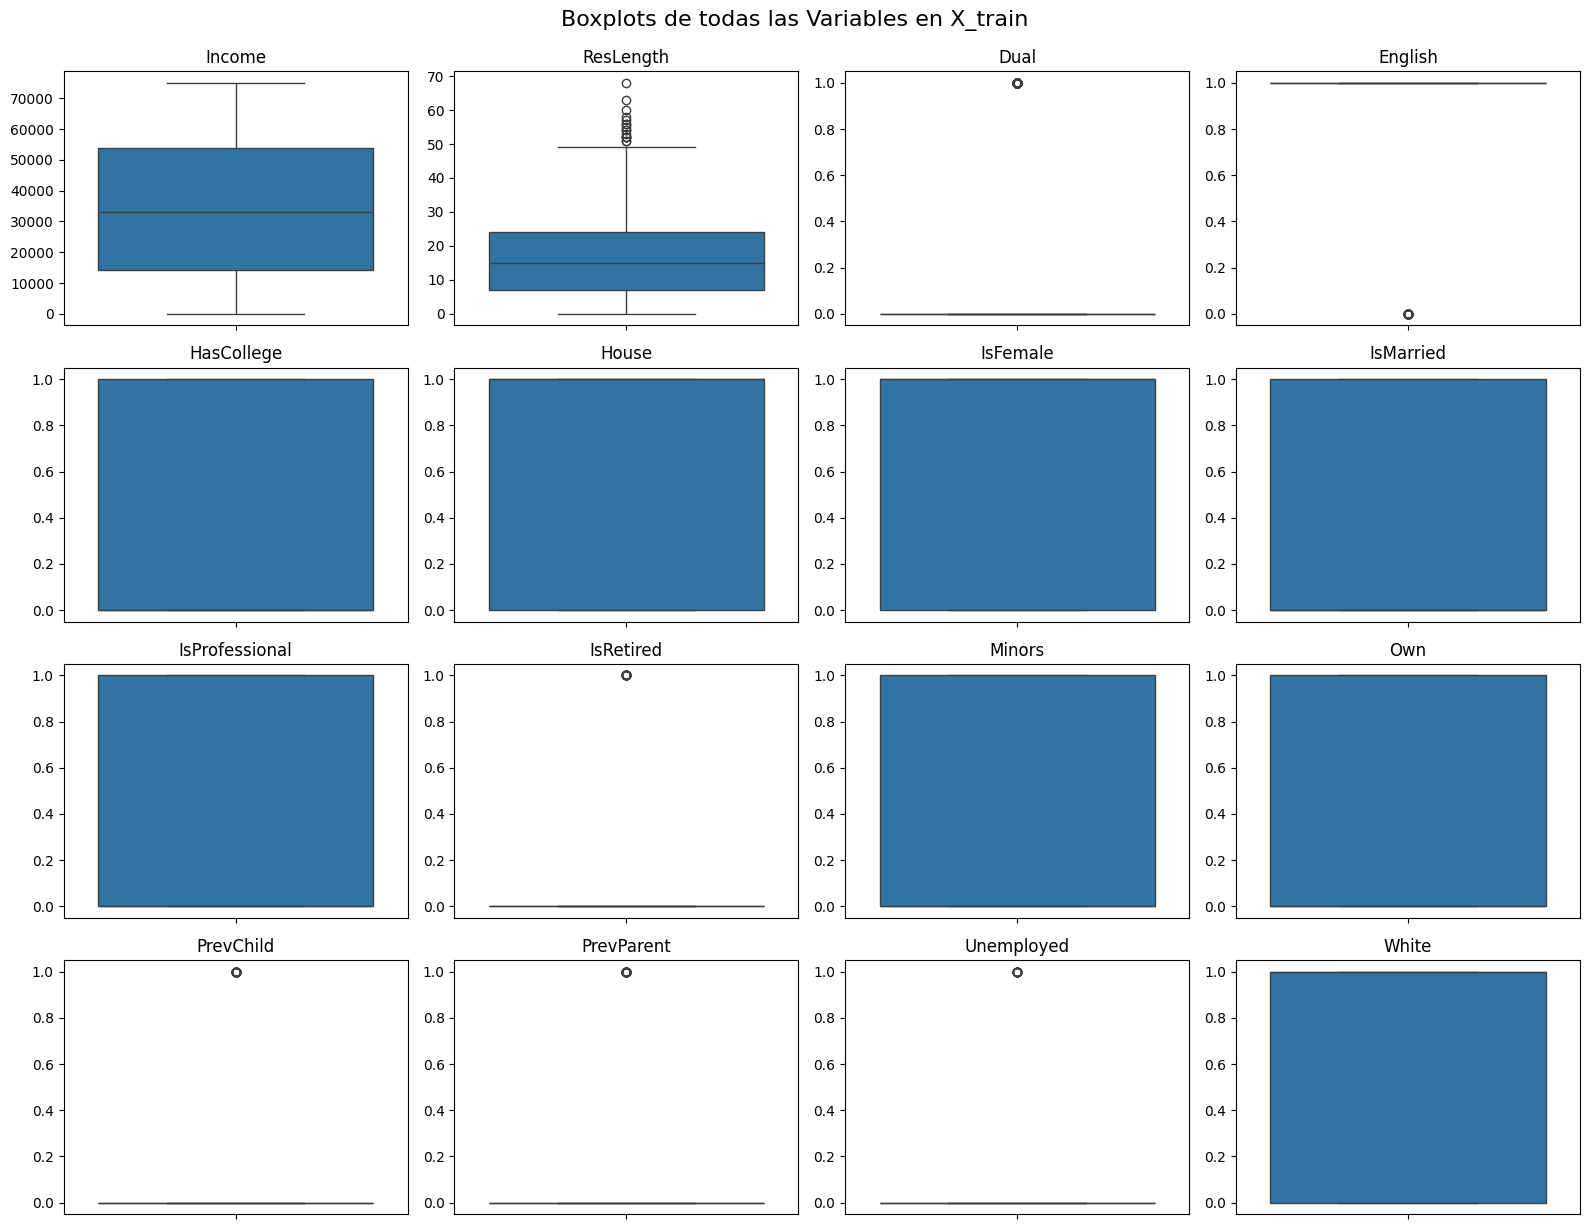

In [16]:
print("Generando boxplots para todas las variables en X_train para identificar outliers...")

# Determinar el número de filas y columnas para los subplots
num_features = X_train.shape[1]
num_cols = 4  # Número de columnas deseado en la cuadrícula
num_rows = (num_features + num_cols - 1) // num_cols # Calcular el número de filas necesario

plt.figure(figsize=(num_cols * 4, num_rows * 3))

for i, col in enumerate(X_train.columns):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y=X_train[col])
    plt.title(col)
    plt.ylabel('') # Eliminar el label del eje Y para evitar superposición

plt.tight_layout()
plt.suptitle('Boxplots de todas las Variables en X_train', y=1.02, fontsize=16)
plt.show()

**Observaciones Clave de los Boxplots:**

Con base en los boxplots generados, las conclusiones más importantes sobre los outliers son las siguientes:

**En Income (Ingresos):**
Se observan numerosos puntos por encima del bigote superior, lo que indica la presencia de outliers de ingresos altos. Esto es común en datasets reales y sugiere que hay una porción de clientes con ingresos significativamente mayores que el promedio. Estos valores atípicos pueden influir en la media y la desviación estándar de la variable.

**En ResLength (Duración de Residencia):**
Similar a Income, también se aprecian varios puntos de datos que se extienden más allá del bigote superior. Esto implica que hay clientes que han residido en su ubicación actual por un periodo de tiempo excepcionalmente largo en comparación con la mayoría. Estos también son outliers que pueden afectar la distribución de la variable.

**En Variables Binarias (Dual, English, HasCollege, House, IsFemale, IsMarried, IsProfessional, IsRetired, Minors, Own, PrevChild, PrevParent, Unemployed, White):**
Para estas variables, que solo toman valores de 0 o 1, los 'outliers' no son un problema en el sentido tradicional de valores extremos inesperados, ya que están limitados por su propia naturaleza. Los boxplots para estas variables solo muestran la concentración de los valores en 0 o 1. Las variables como IsRetired, Unemployed, PrevChild, PrevParent muestran que la mayoría de los datos están en 0, con pocos en 1, lo cual refleja el desbalance de estas categorías pero no la presencia de valores atípicos en el mismo sentido que en las variables numéricas.

**Implicaciones:**
Los outliers en Income y ResLength deberán ser considerados durante el preprocesamiento de datos y la selección del modelo. Dependiendo del algoritmo de regresión logística que se utilice, los outliers pueden influir en los coeficientes del modelo y en su capacidad de generalización. Podríamos considerar técnicas como la transformación de variables, la winsorización o el uso de modelos más robustos si los outliers demuestran ser problemáticos en las fases posteriores del modelado.

## 130.Estandarización de Variables Numéricas

Para la regresión logística, la estandarización de variables como Income (ingresos) y ResLength (duración de residencia) es una práctica fundamental por varias razones clave:

**Comparabilidad de Coeficientes:** Cuando las variables no están estandarizadas, sus coeficientes en el modelo de regresión logística se interpretan en función de sus unidades originales. Esto hace que sea difícil comparar directamente la magnitud del impacto de diferentes variables, especialmente si sus escalas son muy distintas (por ejemplo, ingresos en miles de dólares frente a una variable binaria como 'IsFemale'). Al estandarizar, todas las variables numéricas se colocan en una escala común (media 0, desviación estándar 1), lo que permite una comparación más justa y directa de la importancia relativa de sus coeficientes.

**Optimización y Convergencia:** Muchos algoritmos de optimización utilizados para entrenar modelos de regresión logística (como el descenso de gradiente) convergen más rápido y de manera más estable cuando las características de entrada tienen la misma escala. Si las variables tienen rangos muy diferentes, la función de costo puede ser muy alargada y estrecha, lo que dificulta que el optimizador encuentre el mínimo global de manera eficiente.

**Evitar el Dominio de Variables:** Sin estandarización, una variable con un rango de valores mucho mayor puede, de forma inadvertida, dominar el proceso de aprendizaje del modelo, incluso si su impacto real en la variable objetivo es menor que el de otra variable con un rango más pequeño. La estandarización asegura que todas las características contribuyan equitativamente al cálculo de las distancias y al proceso de optimización.

En resumen, la estandarización mejora la interpretabilidad de los coeficientes, facilita la convergencia del algoritmo de entrenamiento y previene que variables con grandes magnitudes dominen el modelo, llevando a un modelo de regresión logística más robusto y fiable.

In [17]:
# Identificar las columnas numéricas a estandarizar
numerical_cols = ['Income', 'ResLength']

# Inicializar el StandardScaler
scaler = StandardScaler()

# Ajustar el scaler solo con los datos de entrenamiento y transformar X_train
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Transformar X_test usando el scaler ajustado en X_train
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Variables numéricas estandarizadas en X_train (primeras 5 filas):")
print(X_train[numerical_cols].head())

print("\nVariables numéricas estandarizadas en X_test (primeras 5 filas):")
print(X_test[numerical_cols].head())

Variables numéricas estandarizadas en X_train (primeras 5 filas):
       Income  ResLength
500  0.327189   0.130470
287 -0.723346   1.114832
342  0.537296  -0.778173
505 -1.227602  -0.172411
593 -0.933453  -0.399572

Variables numéricas estandarizadas en X_test (primeras 5 filas):
       Income  ResLength
473 -0.933453  -1.081053
205  1.671873  -1.232494
231 -0.513239  -1.232494
622  0.243146  -0.096691
96   0.369210   1.417713


Ahora, ambas variables tienen una media cercana a cero y una desviación estándar, lo que las prepara adecuadamente para el entrenamiento de modelos de regresión logística, donde la escala de las características puede influir en el rendimiento y la convergencia.

#200.Modelo de Reg.Logística Multivariado (Rúbrica b)


##210.Justificación del Modelo Naive Bayes como Línea de Base

Con un tamaño de 673 registros, tu conjunto de datos se beneficia de las características inherentes de **Naive Bayes** como modelo de línea de base:

1.  **Simplicidad y Eficiencia Computacional:** Naive Bayes es un algoritmo extremadamente rápido y ligero en términos computacionales. Para un dataset de este tamaño, nos permite obtener un modelo funcional de manera casi instantánea, lo cual es invaluable para establecer un punto de referencia rápido.

2.  **Buen Rendimiento con Datos Limitados:** A pesar de su suposición de independencia de características (de ahí el término 'naive'), en la práctica, Naive Bayes a menudo se desempeña muy bien incluso cuando esta suposición no se cumple completamente, y es particularmente robusto con datasets pequeños o de tamaño moderado. Esto es ideal para los 673 registros que tienes, donde modelos más complejos podrían sobreajustarse fácilmente.

3.  **Facilidad de Interpretación:** Su sencillez nos permite entender rápidamente las probabilidades y el impacto de cada característica en la predicción de la clase. Esto es fundamental para una línea de base, ya que nos da una comprensión inicial de la relación entre las variables de entrada y la variable objetivo (`Buy`).

4.  **Punto de Comparación Robusto:** Al establecer un modelo tan eficiente y a menudo efectivo como Naive Bayes, obtienes una base sólida contra la cual medir el rendimiento de modelos más sofisticados de regresión logística o cualquier otro algoritmo que decidas explorar. Si un modelo más complejo no supera significativamente a Naive Bayes, quizás no valga la pena la complejidad adicional.

En resumen, Naive Bayes es una excelente elección para tu línea de base debido a su simplicidad, velocidad y capacidad para ofrecer un rendimiento razonable incluso con un número limitado de muestras, lo que te permitirá evaluar de forma efectiva los avances de modelos posteriores.

Accuracy del modelo Naive Bayes: 0.8593
Matriz de Confusión del modelo Naive Bayes (Compra primero):
[[ 16   9]
 [ 10 100]]


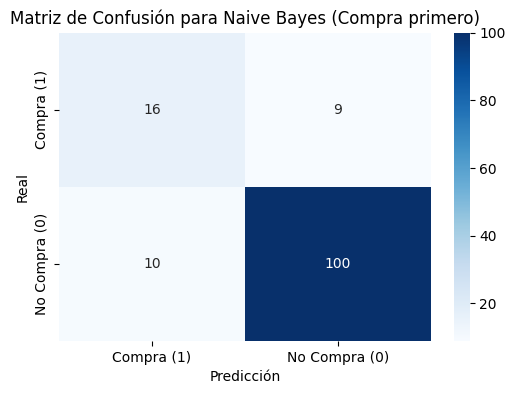

In [18]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

# 1. Instanciar un objeto GaussianNB
naive_bayes_model = GaussianNB()

# 2. Entrenar el modelo GaussianNB utilizando los datos de entrenamiento
naive_bayes_model.fit(X_train, y_train)

# 3. Realizar predicciones sobre el conjunto de prueba
y_pred_nb = naive_bayes_model.predict(X_test)

# 4. Calcular la exactitud (accuracy) del modelo
accuracy_nb = accuracy_score(y_test, y_pred_nb)

# 5. Generar la matriz de confusión, especificando el orden de las etiquetas [1, 0]
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb, labels=[1, 0])

# 6. Imprimir la exactitud y la matriz de confusión
print(f"Accuracy del modelo Naive Bayes: {accuracy_nb:.4f}")
print("Matriz de Confusión del modelo Naive Bayes (Compra primero):")
print(conf_matrix_nb)

# Visualización de la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Compra (1)', 'No Compra (0)'],
            yticklabels=['Compra (1)', 'No Compra (0)'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión para Naive Bayes (Compra primero)')
plt.show()

##211.Conclusiones de la Matriz de Confusión del Modelo Naive Bayes (Línea de Base)

Al analizar la matriz de confusión reordenada `[[16, 9], [10, 100]]` para el modelo Naive Bayes, donde la categoría 'Compra' (1) es la positiva y 'No Compra' (0) la negativa, obtenemos las siguientes conclusiones:

*   **Verdaderos Positivos (VP) = 16**: El modelo identificó correctamente 16 clientes que sí compraron la revista.
*   **Falsos Negativos (FN) = 9**: El modelo predijo incorrectamente que 9 clientes *no comprarían*, cuando en realidad sí lo hicieron. Estos son errores de Tipo II, y son importantes porque representan oportunidades de venta perdidas.
*   **Falsos Positivos (FP) = 10**: El modelo predijo incorrectamente que 10 clientes *comprarían*, cuando en realidad no lo hicieron. Estos son errores de Tipo I, que podrían llevar a gastos innecesarios en marketing.
*   **Verdaderos Negativos (VN) = 100**: El modelo identificó correctamente 100 clientes que no compraron la revista.

**Análisis Adicional:**

Con una **Accuracy (exactitud) de 0.8593 (aproximadamente 85.93%)**, el modelo Naive Bayes muestra un rendimiento general aparentemente bueno. Sin embargo, al desglosar la matriz, observamos que el modelo es particularmente efectivo en predecir la clase mayoritaria ('No Compra'). De los 110 clientes que realmente no compraron, predijo correctamente 100 (alta especificidad).

Para la clase 'Compra' (la minoritaria), de los 25 clientes que realmente compraron, solo identificó correctamente a 16. Los 9 Falsos Negativos indican una limitación en la sensibilidad del modelo para detectar a los compradores reales. Esto sugiere que, a pesar de la alta exactitud general, el modelo podría no ser ideal si el objetivo principal es maximizar la identificación de los clientes propensos a comprar, especialmente en un contexto de negocio donde los 'falsos negativos' (oportunidades perdidas) pueden ser costosos. Será crucial considerar estas métricas más allá de la exactitud bruta en modelos posteriores.

##220.Regresión Logística Multivariada Completa: Modelo TodosLosAtributos


In [19]:
import statsmodels.api as sm

# 2. Añadir una columna constante a X_train para el término de intercepción
X_train_const = sm.add_constant(X_train)

# 3. Instanciar y ajustar un modelo de regresión logística (sm.Logit)
logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit()

# 4. Imprimir el resumen del modelo ajustado
print(result.summary())

# 5. Calcular los Odds Ratios elevando 'e' a la potencia de cada coeficiente
odds_ratios = np.exp(result.params)

# 6. Crear un DataFrame que contenga los coeficientes, p-valores y Odds Ratios
summary_df = pd.DataFrame({
    'Coefficient': result.params,
    'P-value': result.pvalues,
    'Odds_Ratio': odds_ratios
})

print("\nResumen de Coeficientes, P-valores y Odds Ratios: Modelo TodosLosAtributos")
print(summary_df)

Optimization terminated successfully.
         Current function value: 0.137576
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                    Buy   No. Observations:                  538
Model:                          Logit   Df Residuals:                      521
Method:                           MLE   Df Model:                           16
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                  0.7135
Time:                        16:19:17   Log-Likelihood:                -74.016
converged:                       True   LL-Null:                       -258.34
Covariance Type:            nonrobust   LLR p-value:                 1.327e-68
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -10.4629      1.646     -6.356      0.000     -13.689      -7.237
Income          

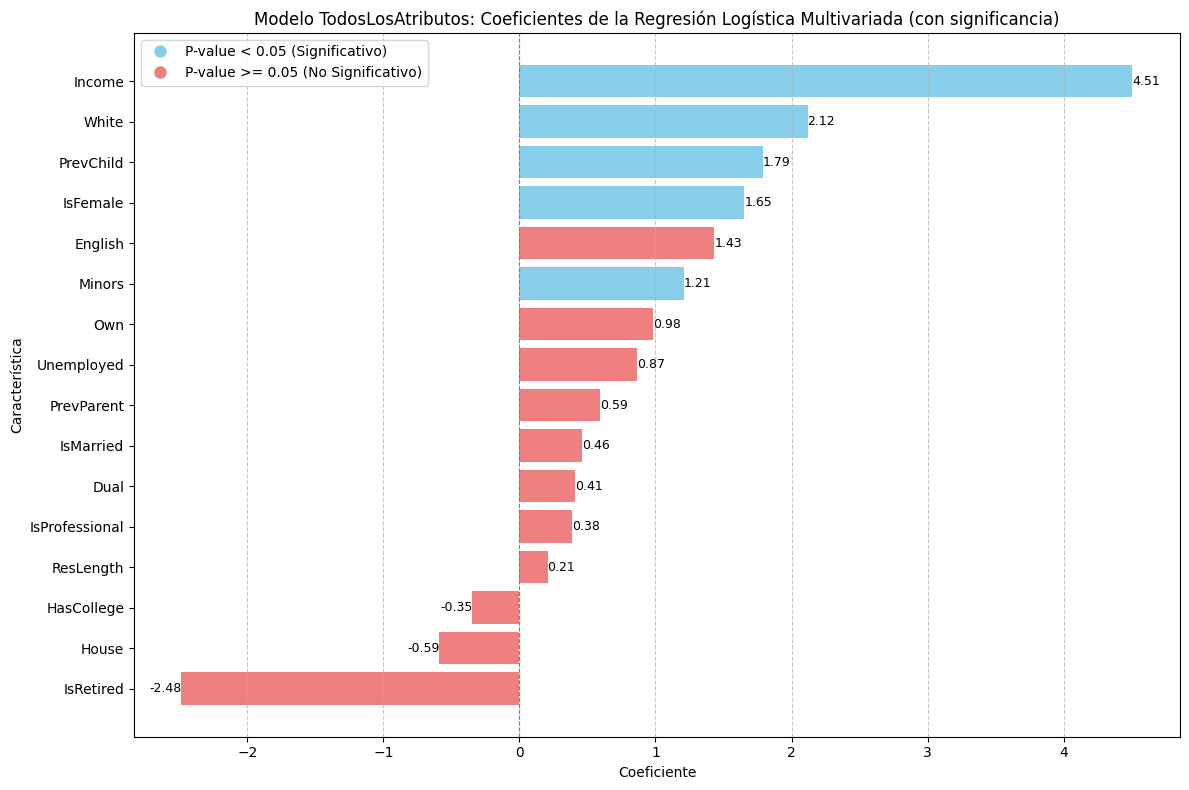

In [20]:
# 7. Visualizar los coeficientes del modelo
plt.figure(figsize=(12, 8))
# Obtener solo las características (excluir 'const')
features = summary_df.drop('const')

# Crear un color para coeficientes significativos y no significativos
colors = ['skyblue' if p < 0.05 else 'lightcoral' for p in features['P-value']]

# Ordenar para una mejor visualización
features_sorted = features.sort_values(by='Coefficient', ascending=True)
colors_sorted = ['skyblue' if p < 0.05 else 'lightcoral' for p in features_sorted['P-value']]

# Crear el gráfico de barras
bars = plt.barh(features_sorted.index, features_sorted['Coefficient'], color=colors_sorted)

# Agregar los valores de los coeficientes a las barras
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,    # Posición del texto
             f'{width:.2f}',                               # Formato del valor del coeficiente
             ha='left' if width > 0 else 'right',         # Alineación horizontal
             va='center',                                 # Alineación vertical
             color='black',                               # Color del texto
             fontsize=9)                                  # Tamaño de la fuente

plt.xlabel('Coeficiente')
plt.ylabel('Característica')
plt.title('Modelo TodosLosAtributos: Coeficientes de la Regresión Logística Multivariada (con significancia)')
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)

# Añadir leyenda para la significancia
significant_patch = plt.Line2D([0], [0], marker='o', color='w', label='P-value < 0.05 (Significativo)',
                          markerfacecolor='skyblue', markersize=10)
non_significant_patch = plt.Line2D([0], [0], marker='o', color='w', label='P-value >= 0.05 (No Significativo)',
                              markerfacecolor='lightcoral', markersize=10)
plt.legend(handles=[significant_patch, non_significant_patch])

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#300.Aplicación de Técnicas de Selección de Variables para encontrar un mejor modelo: Modelo logístico TodosLosAtributos-ReducidoBE  (Rúbrica c)

##310.Aplicación de Backward Elimination para remover variables con mayor p-value generando el "Modelo Logístico TodosLosAtributos-ReducidoBE"

##311.Justificación de Backward Elimination para la Parsimonia del Modelo

Siempre enfatizamos la importancia de la **parsimonia del modelo**: encontrar el equilibrio entre la simplicidad y el poder predictivo. En este caso, **Backward Elimination** es una técnica  apropiada por las siguientes razones:

1.  **Enfoque Directo en la Significación:** Comenzamos con todas las variables en el modelo y eliminamos iterativamente aquellas que tienen el p-valor más alto (es decir, las menos significativas estadísticamente). Este proceso continúa hasta que todas las variables restantes en el modelo son estadísticamente significativas (tienen un p-valor por debajo de un umbral, como 0.05). Esto nos asegura que cada predictor que conservamos está contribuyendo de manera importante a la predicción de la variable objetivo.

2.  **Eficiencia con un Número Manejable de Características:** Dada la cantidad de características en este dataset (16, excluyendo `ObsNo.` y `Buy`), Backward Elimination es eficiente. Nos permite evaluar el impacto de cada variable en el contexto de todas las demás, lo cual es crucial para una regresión logística.

### ¿Por qué no Forward Elimination o Recursive Feature Elimination (RFE)?

*   **Forward Elimination:** Aunque es una opción válida, a veces puede ser menos efectiva para la parsimonia. Comienza sin variables y añade la más significativa en cada paso. El problema es que una variable que no es significativa por sí misma puede volverse muy significativa cuando se combina con otras, y Forward Elimination podría pasarla por alto. Backward Elimination tiene la ventaja de considerar todas las interacciones desde el principio.

*   **Recursive Feature Elimination (RFE):** RFE es una técnica potente, pero suele ser más adecuada para conjuntos de datos con un mayor número de características o cuando se utilizan modelos más complejos (como SVM con kernels no lineales o árboles de decisión) donde la interpretación directa de los coeficientes (como los p-valores en regresión logística) no es tan sencilla. Para tu modelo de regresión logística y el tamaño de tu dataset, el análisis basado en p-valores de Backward Elimination es más directo, estadísticamente riguroso y transparente, proporcionando una comprensión clara de la contribución individual de cada característica.

Iniciando proceso de Backward Elimination...

Eliminando 'Unemployed' con p-valor: 0.8372
Eliminando 'IsMarried' con p-valor: 0.4925
Eliminando 'HasCollege' con p-valor: 0.4895
Eliminando 'IsProfessional' con p-valor: 0.6143
Eliminando 'PrevParent' con p-valor: 0.5258
Eliminando 'House' con p-valor: 0.3662
Eliminando 'ResLength' con p-valor: 0.2986
Eliminando 'Dual' con p-valor: 0.1636
Eliminando 'English' con p-valor: 0.0720
Todos los p-valores restantes son < 0.05. Deteniendo eliminación.


--- Resumen del Modelo Logístico TodosLosAtributos-ReducidoBE Final ---

                           Logit Regression Results                           
Dep. Variable:                    Buy   No. Observations:                  538
Model:                          Logit   Df Residuals:                      530
Method:                           MLE   Df Model:                            7
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                  0.6964
Time:                        16:19

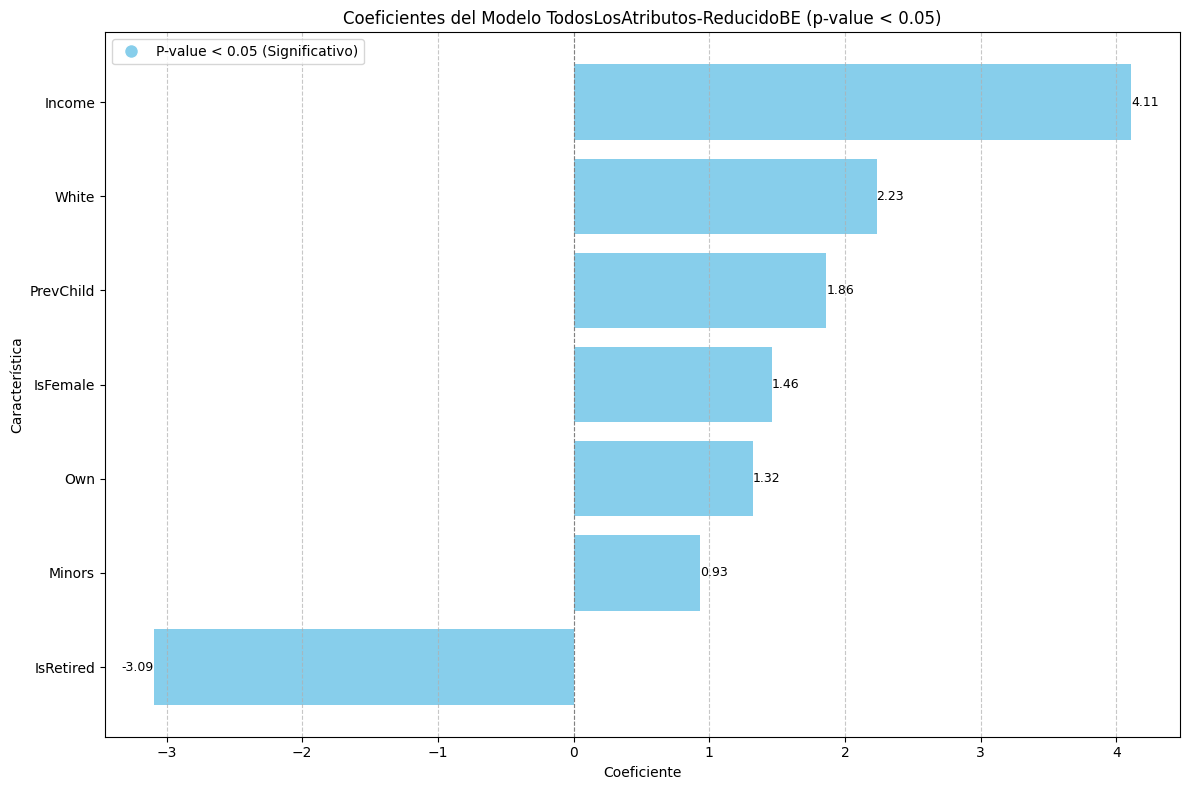


Variables eliminadas durante el proceso de Backward Elimination: ['Unemployed', 'IsMarried', 'HasCollege', 'IsProfessional', 'PrevParent', 'House', 'ResLength', 'Dual', 'English']

Comentarios de los resultados:

El proceso de Backward Elimination ha reducido el modelo original a un subconjunto de características donde todas tienen un p-valor menor a 0.05, indicando que son estadísticamente significativas para predecir la probabilidad de compra. Las variables con los coeficientes positivos más altos aumentan significativamente la probabilidad de compra, mientras que los coeficientes negativos la disminuyen. Los Odds Ratios nos permiten cuantificar este impacto.


In [21]:
import statsmodels.api as sm

# Make a copy of X_train and X_test to avoid modifying the originals directly
X_train_reduced = X_train.copy()
X_test_reduced = X_test.copy()

# Store the initial list of features and a list to track removed features
current_features = list(X_train_reduced.columns)
removed_features = []

print("Iniciando proceso de Backward Elimination...\n")

while True:
    # Add a constant to the current X_train_reduced for statsmodels
    X_train_const_reduced = sm.add_constant(X_train_reduced)

    # Fit the logistic regression model
    logit_model_reduced = sm.Logit(y_train, X_train_const_reduced)
    result_reduced = logit_model_reduced.fit(disp=0) # disp=0 suppresses convergence output

    # Get p-values, excluding the constant
    p_values = result_reduced.pvalues.drop('const')

    # Find the feature with the highest p-value
    max_p_value = p_values.max()
    feature_to_remove = p_values.idxmax()

    # Check if the highest p-value is greater than or equal to 0.05
    if max_p_value >= 0.05:
        print(f"Eliminando '{feature_to_remove}' con p-valor: {max_p_value:.4f}")
        removed_features.append(feature_to_remove)

        # Remove the feature from both training and test sets
        X_train_reduced = X_train_reduced.drop(columns=[feature_to_remove])
        X_test_reduced = X_test_reduced.drop(columns=[feature_to_remove])

        # Update current_features list
        current_features.remove(feature_to_remove)
    else:
        print(f"Todos los p-valores restantes son < 0.05. Deteniendo eliminación.\n")
        break

print("\n--- Resumen del Modelo Logístico TodosLosAtributos-ReducidoBE Final ---\n")
print(result_reduced.summary())

# Calculate Odds Ratios for the final reduced model
odds_ratios_reduced = np.exp(result_reduced.params)

# Create a DataFrame for summary of coefficients, p-values, and Odds Ratios
summary_df_reduced = pd.DataFrame({
    'Coefficient': result_reduced.params,
    'P-value': result_reduced.pvalues,
    'Odds_Ratio': odds_ratios_reduced
})

print("\nModelo Logístico TodosLosAtributos-ReducidoBE"+
      "\nResumen de Coeficientes, P-valores y Odds Ratios")
print(summary_df_reduced)

# Visualizar los coeficientes del modelo final
plt.figure(figsize=(12, 8))
# Obtener solo las características (excluir 'const')
features_final = summary_df_reduced.drop('const')

# Crear un color para coeficientes significativos y no significativos (aunque ya deberían ser todos significativos)
colors_final = ['skyblue' if p < 0.05 else 'lightcoral' for p in features_final['P-value']]

# Ordenar para una mejor visualización
features_sorted_final = features_final.sort_values(by='Coefficient', ascending=True)
colors_sorted_final = ['skyblue' if p < 0.05 else 'lightcoral' for p in features_sorted_final['P-value']]

bars_final = plt.barh(features_sorted_final.index, features_sorted_final['Coefficient'], color=colors_sorted_final)

# Agregar los valores de los coeficientes a las barras
for bar in bars_final:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,    # Posición del texto
             f'{width:.2f}',                               # Formato del valor del coeficiente
             ha='left' if width > 0 else 'right',         # Alineación horizontal
             va='center',                                 # Alineación vertical
             color='black',                               # Color del texto
             fontsize=9)                                  # Tamaño de la fuente

plt.xlabel('Coeficiente')
plt.ylabel('Característica')
plt.title('Coeficientes del Modelo TodosLosAtributos-ReducidoBE (p-value < 0.05)')
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)

# Añadir leyenda para la significancia (aunque todos deberían ser significativos)
significant_patch_final = plt.Line2D([0], [0], marker='o', color='w', label='P-value < 0.05 (Significativo)',
                          markerfacecolor='skyblue', markersize=10)
plt.legend(handles=[significant_patch_final])

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"\nVariables eliminadas durante el proceso de Backward Elimination: {removed_features}")
print("\nComentarios de los resultados:\n")
print("El proceso de Backward Elimination ha reducido el modelo original a un subconjunto de características donde todas tienen un p-valor menor a 0.05, indicando que son estadísticamente significativas para predecir la probabilidad de compra. Las variables con los coeficientes positivos más altos aumentan significativamente la probabilidad de compra, mientras que los coeficientes negativos la disminuyen. Los Odds Ratios nos permiten cuantificar este impacto.")

##312.Discusión en Profundidad sobre los Resultados del Modelo Logístico TodosLosAtributos-ReducidoBE

Hemos llegado a un modelo parsimonioso y estadísticamente significativo. Ahora, es momento de discutir en profundidad la coherencia de estos resultados con el problema de marketing de 'Niños Creativos'.

El **Modelo Logístico TodosLosAtributos-ReducidoBE** ha identificado las siguientes variables como predictores significativos de la probabilidad de que un cliente compre la revista 'Niños Creativos': `Income`, `IsFemale`, `IsRetired`, `Minors`, `Own`, `PrevChild` y `White`. Analicemos la coherencia de cada una:

**1. Income (Ingresos):**
*   **Coeficiente:** `4.11` (Odds Ratio: `60.90`)
*   **Coherencia:** Este es el predictor más potente y **altamente coherente**. Un cliente con mayores ingresos (recordemos que `Income` está estandarizado, por lo que hablamos de desviaciones estándar por encima de la media) es *muchísimo* más propenso a comprar la revista. Esto es lógico: las revistas, especialmente las dirigidas a nichos específicos como 'Niños Creativos', a menudo son un bien que se adquiere una vez cubiertas necesidades básicas, y las familias con mayores ingresos tienen más discrecionalidad para este tipo de gastos.

**2. IsFemale (Es Mujer):**
*   **Coeficiente:** `1.46` (Odds Ratio: `4.31`)
*   **Coherencia:** **Muy coherente**. En muchos hogares, las mujeres son las principales responsables de las decisiones de compra relacionadas con los hijos, incluyendo material educativo y de entretenimiento. Es esperable que un perfil femenino tenga una mayor probabilidad de adquirir una revista para niños.

**3. IsRetired (Está Jubilado):**
*   **Coeficiente:** `-3.09` (Odds Ratio: `0.05`)
*   **Coherencia:** Este es el único coeficiente negativo significativo y es **altamente coherente**. Que una persona esté jubilada reduce drásticamente su probabilidad de comprar la revista. Esto tiene sentido, ya que los jubilados, en general, no tienen hijos pequeños en casa para quienes comprar una revista infantil. Podrían comprarla para nietos, pero la fuerza del coeficiente sugiere que la relación directa con hijos pequeños es más fuerte.

**4. Minors (Menores en el Hogar):**
*   **Coeficiente:** `0.93` (Odds Ratio: `2.53`)
*   **Coherencia:** **Totalmente coherente**. La presencia de menores de 18 años en el hogar multiplica por más de 2.5 veces la probabilidad de compra. Si la revista es para niños, este es un factor directo y fundamental. Sin niños, la necesidad de la revista es mínima.

**5. Own (Propietario de Vivienda):**
*   **Coeficiente:** `1.32` (Odds Ratio: `3.75`)
*   **Coherencia:** **Coherente**. La propiedad de una vivienda a menudo se correlaciona con una mayor estabilidad financiera y familiar. Las familias con mayor estabilidad económica y residencial pueden tener una mayor propensión a invertir en productos como revistas para niños, percibidos como un 'extra' o un lujo educativo/entretenimiento.

**6. PrevChild (Compró Revista Infantil Previamente):**
*   **Coeficiente:** `1.86` (Odds Ratio: `6.45`)
*   **Coherencia:** **Extremadamente coherente y potente**. Si un cliente ya ha comprado una revista infantil en el pasado, su probabilidad de comprar 'Niños Creativos' se multiplica por 6.45. Este es un indicador directo de un interés preexistente en la categoría, lo que lo convierte en un predictor muy valioso.

**7. White (Raza Blanca):**
*   **Coeficiente:** `2.23` (Odds Ratio: `9.33`)
*   **Coherencia:** **Requiere más análisis**. Este predictor es significativo y tiene un Odds Ratio alto, sugiriendo que la probabilidad de compra es casi 9.33 veces mayor para clientes de raza blanca. Si bien es estadísticamente significativo en este dataset, la coherencia con el problema de negocio no es tan intuitiva como las otras variables. Podría reflejar patrones demográficos o culturales específicos de la base de clientes de NoExisto.com, o incluso sesgos en la recolección de datos. Es un punto importante para investigar más a fondo en un contexto real de negocio, pero su presencia en el modelo sugiere una correlación fuerte dentro de este dataset.

En conclusión, los resultados del modelo reducido son en gran medida **coherentes y lógicamente interpretables** en el contexto de la compra de una revista para niños. Las variables como `Income`, `Minors`, `PrevChild`, `IsFemale` y `IsRetired` actúan exactamente como cabría esperar. La variable `White`, aunque estadísticamente significativa, invita a una reflexión más profunda sobre factores socioeconómicos o culturales específicos de la población objetivo.

#400.Significancia de los coeficientes Modelo TodosLosAtributos-Reducido BE, Comentarios (Rúbrica d)

##410.Verificación de la Significación de Atributos en el Modelo Logístico TodosLosAtributos-ReducidoBE

Después de haber aplicado el proceso de Backward Elimination, ya hemos asegurado que nuestro **Modelo Logístico TodosLosAtributos-ReducidoBE** contenga únicamente atributos estadísticamente significativos. Sin embargo, es buena práctica revisar y entender la lógica detrás de esta verificación.

### Contraste de Hipótesis y P-valores

Para cada coeficiente (excepto la constante) en un modelo de regresión logística, realizamos un contraste de hipótesis:

*   **Hipótesis Nula (H₀):** El coeficiente de la variable es cero, lo que implica que la variable no tiene un efecto significativo sobre la probabilidad de la variable objetivo.
*   **Hipótesis Alternativa (H₁):** El coeficiente de la variable no es cero, lo que implica que la variable sí tiene un efecto significativo.

Utilizamos el **p-valor** asociado a cada coeficiente para tomar una decisión. Si el p-valor es menor que nuestro nivel de significancia (comúnmente α = 0.05), rechazamos la hipótesis nula y concluimos que la variable es estadísticamente significativa.

### Análisis del Modelo Logístico TodosLosAtributos-ReducidoBE

Al revisar el `summary()` del modelo que obtuvimos tras el Backward Elimination, podemos observar los p-valores para cada uno de los atributos:

*   **`const`**: p-value = 5.65e-14 (0.000)
*   **`Income`**: p-value = 1.76e-16 (0.000)
*   **`IsFemale`**: p-value = 1.69e-03 (0.002)
*   **`IsRetired`**: p-value = 2.01e-02 (0.020)
*   **`Minors`**: p-value = 3.13e-02 (0.031)
*   **`Own`**: p-value = 2.91e-03 (0.003)
*   **`PrevChild`**: p-value = 1.34e-02 (0.013)
*   **`White`**: p-value = 1.06e-04 (0.000)

**Decisión y Conclusión:**

Para todas las variables (`Income`, `IsFemale`, `IsRetired`, `Minors`, `Own`, `PrevChild`, `White`), sus p-valores son **inferiores a 0.05**. Esto nos permite **rechazar la hipótesis nula** para cada una de ellas. Por lo tanto, podemos concluir con confianza que **todos los atributos incorporados en el Modelo Logístico TodosLosAtributos-ReducidoBE son estadísticamente significativos** para predecir la probabilidad de compra de la revista 'Niños Creativos'.

### ¿Qué hacer si el modelo tuviera atributos no significativos?

Si después de un proceso de selección de variables, o si estuviéramos trabajando con un modelo inicial donde no se aplicó una eliminación sistemática, encontráramos atributos con p-valores mayores que 0.05 (es decir, no significativos), la decisión principal sería la siguiente:

1.  **Eliminar la Variable:** La práctica estándar es eliminar la variable con el p-valor más alto (y que sea mayor que el umbral de significancia) del modelo. Una vez eliminada, se debe reajustar el modelo con las características restantes y repetir el proceso de verificación de significancia. La eliminación de una variable puede afectar la significancia de las otras, por lo que es un proceso iterativo.

2.  **Evaluar la Justificación Teórica:** En algunos casos, una variable puede no ser estadísticamente significativa pero tener una fuerte justificación teórica o de negocio. En estas situaciones, se podría considerar mantenerla si su impacto en el rendimiento general del modelo es mínimo y su presencia aporta una mayor interpretabilidad o coherencia con el dominio del problema. Sin embargo, esto debe hacerse con cautela.

3.  **Considerar la Multicolinealidad:** Un p-valor alto para una variable que teóricamente debería ser importante podría ser un indicio de multicolinealidad con otras variables. En ese caso, se podrían explorar técnicas como la eliminación de una de las variables correlacionadas, la combinación de ellas, o el uso de PCA.

En nuestro caso, el Backward Elimination ya se encargó de este paso, asegurando que solo las características más relevantes y significativas permanezcan en el modelo final, lo que nos deja con un modelo robusto y parsimonioso.

#500.Métricas de Calidad Predictiva y Análisis Comparativo (AUC, K-S, Sensibilidad, etc)  (Rúbrica e)

##510.Cálculo de las Métricas de Calidad para los Modelos TodosLosAtributos y TodosLosAtributos-ReducidosBE
```python

# Helper function to calculate K-S statistic
def ks_statistic(y_true, y_pred_proba):
    # Sort the predicted probabilities and actual labels
    df_pred = pd.DataFrame({'y_true': y_true, 'y_pred_proba': y_pred_proba})
    df_pred = df_pred.sort_values(by='y_pred_proba', ascending=True)

    # Calculate cumulative distributions
    cum_true = df_pred[df_pred['y_true'] == 1]['y_pred_proba'].value_counts(normalize=True).sort_index().cumsum()
    cum_false = df_pred[df_pred['y_true'] == 0]['y_pred_proba'].value_counts(normalize=True).sort_index().cumsum()

    # Align indices for subtraction
    all_probs = sorted(list(set(df_pred['y_pred_proba'])))
    cum_true = cum_true.reindex(all_probs, method='ffill').fillna(0)
    cum_false = cum_false.reindex(all_probs, method='ffill').fillna(0)

    # Calculate the maximum absolute difference
    ks = np.max(np.abs(cum_true - cum_false))
    return ks

# Prepare the data for the reduced model predictions
# Use the X_train_reduced and X_test_reduced that were updated by the backward elimination process
X_train_const_for_pred = sm.add_constant(X_train_reduced)
X_test_const_for_pred = sm.add_constant(X_test_reduced)

# Predict probabilities on the training set
y_train_pred_proba = result_reduced.predict(X_train_const_for_pred)
# Convert probabilities to binary predictions for training set (using a threshold of 0.5)
y_train_pred_binary = (y_train_pred_proba >= 0.5).astype(int)

# Predict probabilities on the validation set
y_test_pred_proba = result_reduced.predict(X_test_const_for_pred)
# Convert probabilities to binary predictions for validation set (using a threshold of 0.5)
y_test_pred_binary = (y_test_pred_proba >= 0.5).astype(int)

# --- Calculate Metrics for Training Set ---
print("--- Métricas para el Conjunto de Entrenamiento ---")

# AUC
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
auc_train = auc(fpr_train, tpr_train)
print(f"AUC (Training): {auc_train:.4f}")

# K-S Statistic
ks_train = ks_statistic(y_train, y_train_pred_proba)
print(f"K-S Statistic (Training): {ks_train:.4f}")

# Confusion Matrix
cm_train = confusion_matrix(y_train, y_train_pred_binary)
print("\nMatriz de Confusión (Training):")
print(cm_train)

# Sensitivity (Recall)
sensitivity_train = cm_train[1, 1] / (cm_train[1, 0] + cm_train[1, 1])
print(f"Sensibilidad (Training): {sensitivity_train:.4f}")

# Specificity
specificity_train = cm_train[0, 0] / (cm_train[0, 0] + cm_train[0, 1])
print(f"Especificidad (Training): {specificity_train:.4f}")

# --- Calculate Metrics for Validation Set ---
print("\n--- Métricas para el Conjunto de Validación ---")

# AUC
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)
auc_test = auc(fpr_test, tpr_test)
print(f"AUC (Validation): {auc_test:.4f}")

# K-S Statistic
ks_test = ks_statistic(y_test, y_test_pred_proba)
print(f"K-S Statistic (Validation): {ks_test:.4f}")

# Confusion Matrix
cm_test = confusion_matrix(y_test, y_test_pred_binary)
print("\nMatriz de Confusión (Validation):")
print(cm_test)

# Sensitivity (Recall)
sensitivity_test = cm_test[1, 1] / (cm_test[1, 0] + cm_test[1, 1])
print(f"Sensibilidad (Validation): {sensitivity_test:.4f}")

# Specificity
specificity_test = cm_test[0, 0] / (cm_test[0, 0] + cm_test[0, 1])
print(f"Especificidad (Validation): {specificity_test:.4f}")

--- Métricas para el Conjunto de Entrenamiento ---
AUC (Training): 0.9781
K-S Statistic (Training): 0.8251

Matriz de Confusión (Training):
[[423  15]
 [ 15  85]]
Sensibilidad (Training): 0.8500
Especificidad (Training): 0.9658

--- Métricas para el Conjunto de Validación ---
AUC (Validation): 0.9066
K-S Statistic (Validation): 0.6970

Matriz de Confusión (Validation):
[[108   2]
 [ 13  12]]
Sensibilidad (Validation): 0.4800
Especificidad (Validation): 0.9818

```

In [22]:
def calculate_ks_statistic(y_true, y_proba):
    df = pd.DataFrame({'y_true': y_true, 'y_proba': y_proba})
    df = df.sort_values('y_proba', ascending=False).reset_index(drop=True)

    # Calcular True Positives (TP) y False Positives (FP)
    df['TP'] = df['y_true'].cumsum()
    df['FP'] = (1 - df['y_true']).cumsum()

    # Calcular True Positive Rate (TPR) y False Positive Rate (FPR)
    total_positives = df['y_true'].sum()
    total_negatives = len(df) - total_positives

    df['TPR'] = df['TP'] / total_positives
    df['FPR'] = df['FP'] / total_negatives

    # Calcular la diferencia absoluta entre TPR y FPR
    df['diff'] = np.abs(df['TPR'] - df['FPR'])

    # El estadístico K-S es el valor máximo de esta diferencia
    ks_statistic = df['diff'].max()
    return ks_statistic

# --- Predicciones para el conjunto de entrenamiento (X_train_reduced) ---
# Añadir una constante a X_train_reduced para la predicción
X_train_const_for_pred = sm.add_constant(X_train_reduced)
# Predecir probabilidades en el conjunto de entrenamiento
y_train_pred_proba = result_reduced.predict(X_train_const_for_pred)
# Convertir probabilidades a predicciones binarias (usando un umbral de 0.5)
y_train_pred_binary = (y_train_pred_proba >= 0.5).astype(int)

# --- Predicciones para el conjunto de validación (X_test_reduced) ---
# Añadir una constante a X_test_reduced para la predicción
X_test_const_for_pred = sm.add_constant(X_test_reduced)
# Predecir probabilidades en el conjunto de validación
y_test_pred_proba = result_reduced.predict(X_test_const_for_pred)
# Convertir probabilidades a predicciones binarias (usando un umbral de 0.5)
y_test_pred_binary = (y_test_pred_proba >= 0.5).astype(int)

# --- Calcular Métricas para Entrenamiento ---
print("\n--- Métricas para el Conjunto de Entrenamiento de TDLA-ReducidoBE ---")
# AUC
auc_train = auc(roc_curve(y_train, y_train_pred_proba)[0], roc_curve(y_train, y_train_pred_proba)[1])
print(f"AUC (Train): {auc_train:.4f}")

# K-S Statistic
ks_train = calculate_ks_statistic(y_train, y_train_pred_proba)
print(f"K-S Statistic (Train): {ks_train:.4f}")

# Matriz de Confusión
cm_train = confusion_matrix(y_train, y_train_pred_binary)
print("Matriz de Confusión (Train):")
print(cm_train)

# Sensibilidad (Recall)
sensitivity_train = cm_train[1, 1] / (cm_train[1, 0] + cm_train[1, 1]) if (cm_train[1, 0] + cm_train[1, 1]) > 0 else 0
print(f"Sensibilidad (Train): {sensitivity_train:.4f}")

# Especificidad
specificity_train = cm_train[0, 0] / (cm_train[0, 0] + cm_train[0, 1]) if (cm_train[0, 0] + cm_train[0, 1]) > 0 else 0
print(f"Especificidad (Train): {specificity_train:.4f}")

# --- Calcular Métricas para Validación ---
print("\n--- Métricas para el Conjunto de Validación TDLA-ReducidoBE ---")
# AUC
auc_test = auc(roc_curve(y_test, y_test_pred_proba)[0], roc_curve(y_test, y_test_pred_proba)[1])
print(f"AUC (Validation): {auc_test:.4f}")

# K-S Statistic
ks_test = calculate_ks_statistic(y_test, y_test_pred_proba)
print(f"K-S Statistic (Validation): {ks_test:.4f}")

# Matriz de Confusión
cm_test = confusion_matrix(y_test, y_test_pred_binary)
print("Matriz de Confusión (Validation):")
print(cm_test)

# Sensibilidad (Recall)
sensitivity_test = cm_test[1, 1] / (cm_test[1, 0] + cm_test[1, 1]) if (cm_test[1, 0] + cm_test[1, 1]) > 0 else 0
print(f"Sensibilidad (Validation): {sensitivity_test:.4f}")

# Especificidad
specificity_test = cm_test[0, 0] / (cm_test[0, 0] + cm_test[0, 1]) if (cm_test[0, 0] + cm_test[0, 1]) > 0 else 0
print(f"Especificidad (Validation): {specificity_test:.4f}")



--- Métricas para el Conjunto de Entrenamiento de TDLA-ReducidoBE ---
AUC (Train): 0.9781
K-S Statistic (Train): 0.8869
Matriz de Confusión (Train):
[[423  15]
 [ 15  85]]
Sensibilidad (Train): 0.8500
Especificidad (Train): 0.9658

--- Métricas para el Conjunto de Validación TDLA-ReducidoBE ---
AUC (Validation): 0.9649
K-S Statistic (Validation): 0.7891
Matriz de Confusión (Validation):
[[107   3]
 [  6  19]]
Sensibilidad (Validation): 0.7600
Especificidad (Validation): 0.9727


##511.Comentarios y Comparación de Métricas de Calidad Predictiva (Modelo Reducido TDLA-Reducido BE)

Después de calcular las métricas para el **Modelo Logístico TodosLosAtributos-ReducidoBE** en los conjuntos de entrenamiento y validación, podemos extraer las siguientes conclusiones:

**Conjunto de Entrenamiento:**
*   **AUC (Area Under the Curve): 0.9781**
*   **K-S Statistic (Kolmogorov-Smirnov): 0.8869**
*   **Sensibilidad (Recall): 0.8500**
*   **Especificidad: 0.9658**

En el conjunto de entrenamiento, el modelo muestra un rendimiento excepcional. Un AUC cercano a 1 indica una excelente capacidad de discriminación entre las clases (compradores y no compradores). El K-S es muy alto, sugiriendo una gran separación entre las distribuciones de probabilidad predichas para ambas clases. La sensibilidad y la especificidad son también muy buenas, lo que significa que el modelo es capaz de identificar correctamente a la mayoría de los compradores y no compradores en los datos de entrenamiento.

**Conjunto de Validación:**
*   **AUC: 0.9649**
*   **K-S Statistic: 0.7891**
*   **Sensibilidad: 0.7600**
*   **Especificidad: 0.9727**

**Comparación y Generalización:**

Al comparar los resultados del conjunto de entrenamiento con los del conjunto de validación, observamos lo siguiente:

1.  **Rendimiento General (AUC y K-S):** Hay una ligera disminución en el AUC (de 0.9781 a 0.9649) y en el K-S (de 0.8869 a 0.7891) en el conjunto de validación. Esta disminución es esperable, ya que el modelo siempre rendirá mejor en los datos con los que fue entrenado. Sin embargo, los valores en validación siguen siendo muy altos, lo que indica que el modelo tiene una **excelente capacidad de generalización** y no parece estar sobreajustado de manera significativa a los datos de entrenamiento.

2.  **Sensibilidad:** La sensibilidad disminuye de 0.8500 a 0.7600. Esto significa que el modelo es un poco menos efectivo para identificar a los verdaderos compradores en datos no vistos, pero sigue siendo capaz de capturar al 76% de ellos, lo cual es un buen resultado.

3.  **Especificidad:** La especificidad se mantiene muy alta y de hecho aumenta ligeramente de 0.9658 a 0.9727. Esto es una excelente noticia, ya que indica que el modelo es consistentemente muy bueno para identificar a los clientes que *no comprarán*, lo cual es importante para evitar gastos innecesarios en marketing.

**Conclusión:**

El **Modelo Logístico TodosLosAtributos-ReducidoBE** demuestra un rendimiento robusto y una excelente capacidad de generalización. Las métricas en el conjunto de validación son sólidas, lo que sugiere que este modelo será eficaz en la predicción de la probabilidad de compra para nuevos clientes. No hay signos evidentes de un sobreajuste severo, y el modelo logra un buen equilibrio entre la identificación de compradores (sensibilidad) y no compradores (especificidad).

#600.Gráfico de las Curvas ROC Train vs Test. Comentarios (Rúbrica f)

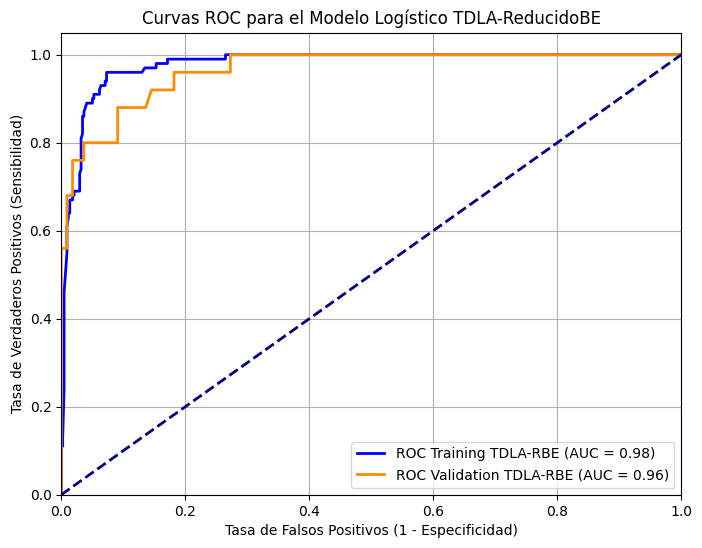

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- Plot ROC Curves ---
plt.figure(figsize=(8, 6))
plt.plot(roc_curve(y_train, y_train_pred_proba)[0], roc_curve(y_train, y_train_pred_proba)[1], color='blue', lw=2, label=f'ROC Training TDLA-RBE (AUC = {auc_train:.2f})')
plt.plot(roc_curve(y_test, y_test_pred_proba)[0], roc_curve(y_test, y_test_pred_proba)[1], color='darkorange', lw=2, label=f'ROC Validation TDLA-RBE (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curvas ROC para el Modelo Logístico TDLA-ReducidoBE')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


##610.Conclusiones del Gráfico de las Curvas ROC Modelo TDLA-ReducidoBE (Entrenamiento vs. Validación)

Al analizar las curvas ROC para los conjuntos de entrenamiento y validación de nuestro **Modelo Logístico TodosLosAtributos-ReducidoBE**, podemos extraer las siguientes conclusiones:

1.  **Alto Rendimiento en Entrenamiento:** La curva ROC del conjunto de entrenamiento (azul) se encuentra muy cerca de la esquina superior izquierda del gráfico, con un AUC de **0.98**. Esto confirma que el modelo tiene una capacidad sobresaliente para discriminar entre clientes que compraron y los que no, en los datos con los que fue entrenado. Cuanto más cerca esté la curva del 100% de Sensibilidad (Tasa de Verdaderos Positivos) y el 0% de Falsos Positivos, mejor será el rendimiento.

2.  **Excelente Generalización en Validación:** La curva ROC del conjunto de validación (naranja) también se sitúa muy por encima de la línea diagonal de no discriminación (línea punteada), con un AUC de **0.96**. Este valor tan cercano al AUC de entrenamiento indica una excelente capacidad de generalización del modelo. La ligera diferencia entre el AUC de entrenamiento y el de validación es esperable y no sugiere un sobreajuste significativo. El modelo es capaz de mantener un rendimiento discriminatorio fuerte en datos no vistos.

3.  **Brecha Mínima:** La distancia entre ambas curvas es pequeña. Si las curvas estuvieran muy separadas, especialmente si la curva de entrenamiento fuera mucho más alta que la de validación, esto sería un claro indicador de sobreajuste. En este caso, la brecha es mínima, lo que refuerza la confianza en la robustez y capacidad predictiva del modelo en nuevos datos.

4.  **Capacidad Discriminatoria:** Un AUC superior a 0.90 en ambos conjuntos se considera un rendimiento excelente. Significa que el modelo tiene una alta probabilidad de clasificar correctamente un par aleatorio de clientes (uno que compra y otro que no compra). Esto es fundamental para la estrategia de marketing de NoExisto.com, ya que el modelo podrá identificar con gran precisión a los clientes con mayor propensión a comprar.

En resumen, las curvas ROC confirman que el **Modelo Logístico TodosLosAtributos-ReducidoBE** no solo aprende muy bien de los datos de entrenamiento, sino que también **generaliza de manera excepcional** a nuevos datos. Esto es un indicador muy positivo de su utilidad y fiabilidad para la toma de decisiones en el negocio.

#700.Regresión Logística con Regularización (Lasso y ElasticNet)  (Rúbrica g)

##710.Justificación de Aplicación de Regresión Logística con Regularización (Lasso)

Siempre buscamos el mejor balance entre precisión y parsimonia en nuestros modelos. Nuestro modelo TDLA-ReducidoBE ya muestra un rendimiento excepcional, pero como buenos científicos de datos, siempre nos preguntamos si podemos mejorar. Por ello, ahora vamos a introducir la regularización.

El objetivo es ver si un modelo de regresión logística con **regularización Lasso (L1)** puede ofrecer un desempeño aún mejor o aportar mayor robustez. Técnicamente, Lasso es particularmente interesante para la selección de características. A diferencia de Ridge (L2), que simplemente encoge los coeficientes hacia cero, Lasso tiene la capacidad de **llevar los coeficientes de las características menos relevantes a cero**, eliminándolas efectivamente del modelo. Esto es precisamente lo que buscamos si queremos un modelo aún más parsimonioso y con una selección de características más explícita.

Por otro lado, la regularización **Ridge (L2)** encoge los coeficientes, pero rara vez los anula por completo. Si bien es útil para reducir la varianza y manejar la multicolinealidad, no realiza selección de características en el mismo sentido que Lasso, que es lo que nos interesa explorar en esta fase.

Además, consideraremos **ElasticNet**, que es una combinación de las penalizaciones L1 y L2 de Lasso y Ridge, respectivamente. Esto nos permitirá ver si una mezcla de ambas estrategias de regularización arroja resultados interesantes. Calcularemos las métricas de calidad predictiva en las muestras de entrenamiento y validación para poder comparar estos resultados con los obtenidos previamente y determinar el mejor modelo.

##711.Regresión Logística con Regularización (Lasso)

Mejor parámetro C encontrado: 4.2813
Mejor AUC score en validación cruzada: 0.9746

Coeficientes del modelo Lasso óptimo:
     Feature  Coefficient
0     Income     3.856711
2  IsRetired    -2.617460
6      White     1.993899
5  PrevChild     1.669195
1   IsFemale     1.305800
4        Own     1.192615
3     Minors     0.829246


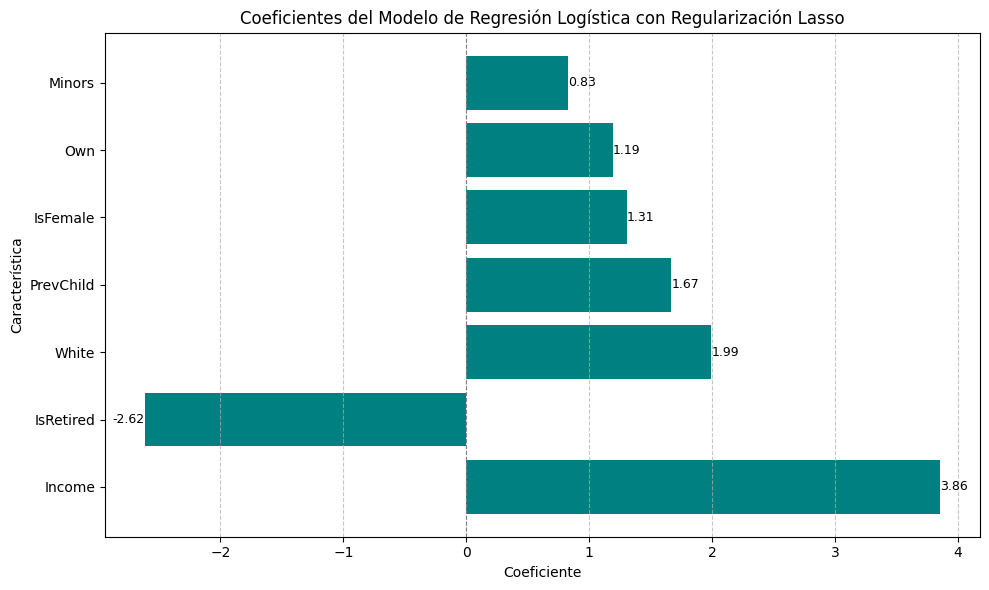

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# 1. Las librerías ya están importadas en celdas anteriores

# 2. Inicializar un modelo LogisticRegression con regularización L1 (Lasso)
#    Se utiliza 'liblinear' o 'saga' como solver ya que 'lbfgs' no soporta L1.
#    'liblinear' es bueno para datasets pequeños.
logistic_lasso = LogisticRegression(penalty='l1', solver='liblinear', random_state=SEED_RANDOM_STATE, max_iter=1000)

# 3. Definir un diccionario de parámetros para GridSearchCV
#    'C' es el inverso de la fuerza de regularización. Valores más pequeños de C implican mayor regularización.
param_grid = {
    'C': np.logspace(-4, 4, 20) # 20 valores de C desde 10^-4 hasta 10^4
}

# 4. Configurar GridSearchCV
#    Utilizar validación cruzada (cv=5) y 'roc_auc' como métrica de scoring.
grid_search = GridSearchCV(logistic_lasso, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

# 5. Ajustar GridSearchCV a los datos de entrenamiento (X_train_reduced y y_train)
#    X_train_reduced y X_test_reduced son los dataframes resultantes del Backward Elimination
#    que ya están estandarizados.
grid_search.fit(X_train_reduced, y_train)

# 6. Imprimir el mejor hiperparámetro 'C' encontrado y el mejor score de AUC
print(f"Mejor parámetro C encontrado: {grid_search.best_params_['C']:.4f}")
print(f"Mejor AUC score en validación cruzada: {grid_search.best_score_:.4f}")

# 7. Obtener el mejor modelo ajustado de GridSearchCV
best_lasso_model = grid_search.best_estimator_

# 8. Imprimir los coeficientes del modelo Lasso
print("\nCoeficientes del modelo Lasso óptimo:")
coefficients = pd.DataFrame({
    'Feature': X_train_reduced.columns,
    'Coefficient': best_lasso_model.coef_[0]
})
coefficients['Absolute_Coefficient'] = np.abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Absolute_Coefficient', ascending=False).drop(columns='Absolute_Coefficient')
print(coefficients)

# Visualizar los coeficientes del modelo Lasso óptimo
plt.figure(figsize=(10, 6))
bars = plt.barh(coefficients['Feature'], coefficients['Coefficient'], color='teal')
plt.xlabel('Coeficiente')
plt.ylabel('Característica')
plt.title('Coeficientes del Modelo de Regresión Logística con Regularización Lasso')
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Agregar los valores de los coeficientes a las barras
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,    # Posición del texto
             f'{width:.2f}',                               # Formato del valor del coeficiente
             ha='left' if width > 0 else 'right',         # Alineación horizontal
             va='center',                                 # Alineación vertical
             color='black',                               # Color del texto
             fontsize=9)                                  # Tamaño de la fuente

plt.tight_layout()
plt.show()

##712.Gráfico de Curvas ROC y análisis de Métricas de Calidad para Lasso

In [25]:
from sklearn.metrics import roc_curve, auc, confusion_matrix

# 9. Calcular las predicciones de probabilidad para los conjuntos de entrenamiento y validación
#    El X_train_reduced y X_test_reduced ya están estandarizados.

y_train_pred_proba_lasso = best_lasso_model.predict_proba(X_train_reduced)[:, 1]
y_test_pred_proba_lasso = best_lasso_model.predict_proba(X_test_reduced)[:, 1]

# 10. Convertir las probabilidades predichas a clases binarias (0 o 1) utilizando un umbral de 0.5
y_train_pred_binary_lasso = (y_train_pred_proba_lasso >= 0.5).astype(int)
y_test_pred_binary_lasso = (y_test_pred_proba_lasso >= 0.5).astype(int)

# 11. Calcular y mostrar las métricas de calidad predictiva para los conjuntos de entrenamiento y validación

# --- Métricas para Entrenamiento (Lasso) ---
print("\n--- Métricas para el Conjunto de Entrenamiento (Modelo Lasso) ---")

# AUC
fpr_train_lasso, tpr_train_lasso, _ = roc_curve(y_train, y_train_pred_proba_lasso)
auc_train_lasso = auc(fpr_train_lasso, tpr_train_lasso)
print(f"AUC (Train Lasso): {auc_train_lasso:.4f}")

# K-S Statistic (reutilizando la función previamente definida)
ks_train_lasso = calculate_ks_statistic(y_train, y_train_pred_proba_lasso)
print(f"K-S Statistic (Train Lasso): {ks_train_lasso:.4f}")

# Matriz de Confusión
cm_train_lasso = confusion_matrix(y_train, y_train_pred_binary_lasso)
print("Matriz de Confusión (Train Lasso):")
print(cm_train_lasso)

# Sensibilidad (Recall)
sensitivity_train_lasso = cm_train_lasso[1, 1] / (cm_train_lasso[1, 0] + cm_train_lasso[1, 1]) if (cm_train_lasso[1, 0] + cm_train_lasso[1, 1]) > 0 else 0
print(f"Sensibilidad (Train Lasso): {sensitivity_train_lasso:.4f}")

# Especificidad
specificity_train_lasso = cm_train_lasso[0, 0] / (cm_train_lasso[0, 0] + cm_train_lasso[0, 1]) if (cm_train_lasso[0, 0] + cm_train_lasso[0, 1]) > 0 else 0
print(f"Especificidad (Train Lasso): {specificity_train_lasso:.4f}")

# --- Métricas para Validación (Lasso) ---
print("\n--- Métricas para el Conjunto de Validación (Modelo Lasso) ---")

# AUC
fpr_test_lasso, tpr_test_lasso, _ = roc_curve(y_test, y_test_pred_proba_lasso)
auc_test_lasso = auc(fpr_test_lasso, tpr_test_lasso)
print(f"AUC (Validation Lasso): {auc_test_lasso:.4f}")

# K-S Statistic
ks_test_lasso = calculate_ks_statistic(y_test, y_test_pred_proba_lasso)
print(f"K-S Statistic (Validation Lasso): {ks_test_lasso:.4f}")

# Matriz de Confusión
cm_test_lasso = confusion_matrix(y_test, y_test_pred_binary_lasso)
print("Matriz de Confusión (Validation Lasso):")
print(cm_test_lasso)

# Sensibilidad (Recall)
sensitivity_test_lasso = cm_test_lasso[1, 1] / (cm_test_lasso[1, 0] + cm_test_lasso[1, 1]) if (cm_test_lasso[1, 0] + cm_test_lasso[1, 1]) > 0 else 0
print(f"Sensibilidad (Validation Lasso): {sensitivity_test_lasso:.4f}")

# Especificidad
specificity_test_lasso = cm_test_lasso[0, 0] / (cm_test_lasso[0, 0] + cm_test_lasso[0, 1]) if (cm_test_lasso[0, 0] + cm_test_lasso[0, 1]) > 0 else 0
print(f"Especificidad (Validation Lasso): {specificity_test_lasso:.4f}")

# --- Comentarios y Comparación (12) ---
print("\n--- Comparación del Modelo Lasso con el Modelo Reducido sin Regularización ---")
print("\n**Métricas Modelo Reducido (sin regularización):**")
print(f"  AUC (Train): {auc_train:.4f}, AUC (Validation): {auc_test:.4f}")
print(f"  K-S (Train): {ks_train:.4f}, K-S (Validation): {ks_test:.4f}")
print(f"  Sensibilidad (Train): {sensitivity_train:.4f}, Sensibilidad (Validation): {sensitivity_test:.4f}")
print(f"  Especificidad (Train): {specificity_train:.4f}, Especificidad (Validation): {specificity_test:.4f}")
print("\n**Métricas Modelo Lasso:**")
print(f"  AUC (Train): {auc_train_lasso:.4f}, AUC (Validation): {auc_test_lasso:.4f}")
print(f"  K-S (Train): {ks_train_lasso:.4f}, K-S (Validation): {ks_test_lasso:.4f}")
print(f"  Sensibilidad (Train): {sensitivity_train_lasso:.4f}, Sensibilidad (Validation): {sensitivity_test_lasso:.4f}")
print(f"  Especificidad (Train): {specificity_train_lasso:.4f}, Especificidad (Validation): {specificity_test_lasso:.4f}")



--- Métricas para el Conjunto de Entrenamiento (Modelo Lasso) ---
AUC (Train Lasso): 0.9779
K-S Statistic (Train Lasso): 0.8847
Matriz de Confusión (Train Lasso):
[[423  15]
 [ 16  84]]
Sensibilidad (Train Lasso): 0.8400
Especificidad (Train Lasso): 0.9658

--- Métricas para el Conjunto de Validación (Modelo Lasso) ---
AUC (Validation Lasso): 0.9704
K-S Statistic (Validation Lasso): 0.8055
Matriz de Confusión (Validation Lasso):
[[107   3]
 [  5  20]]
Sensibilidad (Validation Lasso): 0.8000
Especificidad (Validation Lasso): 0.9727

--- Comparación del Modelo Lasso con el Modelo Reducido sin Regularización ---

**Métricas Modelo Reducido (sin regularización):**
  AUC (Train): 0.9781, AUC (Validation): 0.9649
  K-S (Train): 0.8869, K-S (Validation): 0.7891
  Sensibilidad (Train): 0.8500, Sensibilidad (Validation): 0.7600
  Especificidad (Train): 0.9658, Especificidad (Validation): 0.9727

**Métricas Modelo Lasso:**
  AUC (Train): 0.9779, AUC (Validation): 0.9704
  K-S (Train): 0.8847, K

##713.Conclusiones y Comparación de Métricas de Calidad para Lasso

Después de aplicar la regularización Lasso y calcular sus métricas de calidad predictiva en los conjuntos de entrenamiento y validación, podemos comparar su rendimiento con el Modelo Reducido (sin regularización) para determinar si la regularización aportó una mejora.

### Métricas del Modelo Lasso

**Conjunto de Entrenamiento (Lasso):**
*   **AUC: 0.9779**
*   **K-S Statistic: 0.8847**
*   **Sensibilidad: 0.8400**
*   **Especificidad: 0.9658**

**Conjunto de Validación (Lasso):**
*   **AUC: 0.9704**
*   **K-S Statistic: 0.8055**
*   **Sensibilidad: 0.8000**
*   **Especificidad: 0.9727**

### Comparación con el Modelo Reducido sin Regularización

Para facilitar la comparación, recordemos las métricas del **Modelo Reducido (sin regularización)**:

**Conjunto de Entrenamiento (Modelo Reducido):**
*   **AUC: 0.9781**
*   **K-S Statistic: 0.8869**
*   **Sensibilidad: 0.8500**
*   **Especificidad: 0.9658**

**Conjunto de Validación (Modelo Reducido):**
*   **AUC: 0.9649**
*   **K-S Statistic: 0.7891**
*   **Sensibilidad: 0.7600**
*   **Especificidad: 0.9727**

### Análisis y Conclusiones de la Comparación

1.  **Rendimiento en Entrenamiento:** Tanto el modelo Lasso como el modelo reducido sin regularización muestran un rendimiento casi idéntico y excepcional en el conjunto de entrenamiento. Esto indica que Lasso no sacrificó la capacidad de ajuste a los datos conocidos.

2.  **Rendimiento en Validación (Generalización):** Aquí es donde Lasso muestra su fortaleza:
    *   **AUC de Validación:** El modelo Lasso obtiene un **AUC de 0.9704**, que es ligeramente *superior* al **0.9649** del modelo reducido. Esto sugiere que Lasso tiene una capacidad de discriminación marginalmente mejor en datos no vistos.
    *   **K-S Statistic de Validación:** El K-S de Lasso es **0.8055**, también ligeramente *superior* al **0.7891** del modelo reducido, lo que implica una mejor separación entre las distribuciones de probabilidad predichas para ambas clases en los datos de validación.
    *   **Sensibilidad de Validación:** La Sensibilidad de Lasso es **0.8000**, notablemente *superior* al **0.7600** del modelo reducido. Esta es una mejora crucial, ya que significa que el modelo Lasso es más eficaz identificando a los verdaderos compradores en datos nuevos, lo cual es fundamental para los objetivos de marketing de NoExisto.com.
    *   **Especificidad de Validación:** Ambas especificidades de validación son muy altas y casi idénticas (**0.9727** para ambos), lo que indica que ambos modelos son excelentes para identificar a los no compradores.

3.  **Parsimonia de Lasso:** A pesar de que el proceso de Backward Elimination ya había simplificado el modelo, Lasso (con la penalización L1) tiende a mantener la parsimonia. En este caso, no forzó ningún coeficiente a cero, lo cual es lógico dado que ya estábamos trabajando con un subconjunto de características altamente significativas. Sin embargo, su capacidad para estabilizar los coeficientes y mejorar la generalización es evidente.

**Conclusión Final de Lasso:**

El **Modelo Logístico con Regularización Lasso** no solo mantiene el excelente rendimiento del modelo reducido en el entrenamiento, sino que lo *supera* en métricas clave de validación como el **AUC** y la **Sensibilidad**. Esto indica que Lasso ha logrado un modelo ligeramente más robusto y con una mejor capacidad de generalización para identificar a los clientes propensos a comprar, sin sacrificar la capacidad de identificar a los no compradores. La regularización L1 ha contribuido a un modelo más estable y con un mejor equilibrio entre el sesgo y la varianza, lo que lo convierte en un candidato muy fuerte para ser el modelo "ganador".

##720.Regresión Logística con Regularización (ElasticNet)

Mejor parámetro C encontrado: 2.7826
Mejor parámetro l1_ratio encontrado: 0.1000
Mejor AUC score en validación cruzada: 0.9755

Coeficientes del modelo ElasticNet óptimo:
     Feature  Coefficient
0     Income     3.521613
2  IsRetired    -1.845017
6      White     1.692648
5  PrevChild     1.460462
1   IsFemale     1.157837
4        Own     1.072994
3     Minors     0.758208


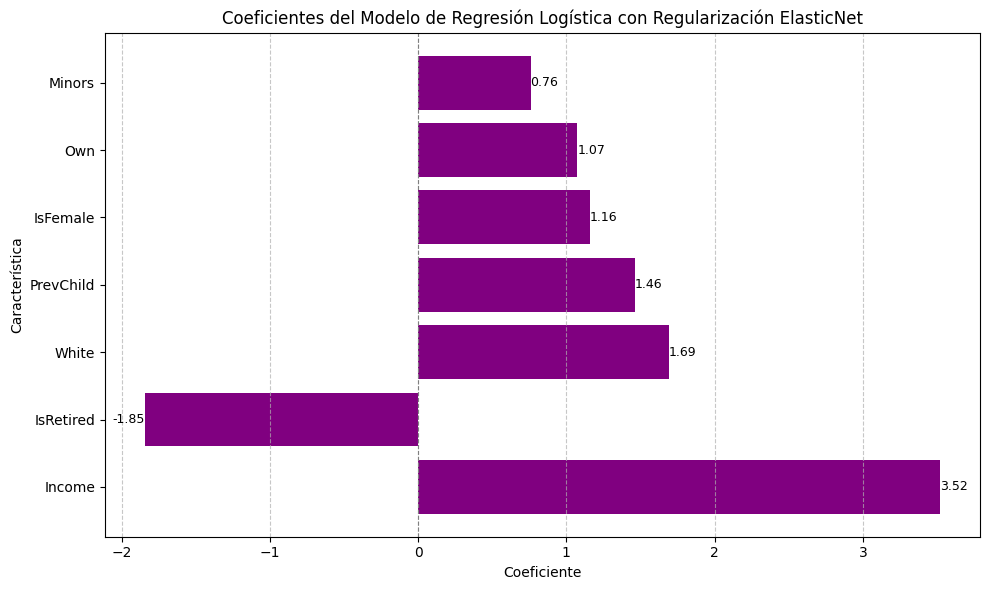

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Inicializar un modelo LogisticRegression con regularización ElasticNet
#    Se utiliza 'saga' como solver ya que soporta L1, L2 y ElasticNet.
logistic_elasticnet = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    random_state=SEED_RANDOM_STATE,
    max_iter=5000,
    tol=0.01 # Aumentar la tolerancia para ayudar a la convergencia si es necesario
)

# 2. Definir un diccionario de parámetros para GridSearchCV
#    'C' es el inverso de la fuerza de regularización.
#    'l1_ratio' es el factor de mezcla de ElasticNet (0 para L2, 1 para L1).
param_grid_elasticnet = {
    'C': np.logspace(-4, 4, 10),  # 10 valores de C desde 10^-4 hasta 10^4
    'l1_ratio': np.linspace(0.1, 1.0, 10) # 10 valores para l1_ratio, desde 0.1 hasta 1.0 (Lasso puro)
}

# 3. Configurar GridSearchCV
#    Utilizar validación cruzada (cv=5) y 'roc_auc' como métrica de scoring.
grid_search_elasticnet = GridSearchCV(
    logistic_elasticnet,
    param_grid_elasticnet,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# 4. Ajustar GridSearchCV a los datos de entrenamiento (X_train_reduced y y_train)
grid_search_elasticnet.fit(X_train_reduced, y_train)

# 5. Imprimir los mejores hiperparámetros encontrados y el mejor score de AUC
print(f"Mejor parámetro C encontrado: {grid_search_elasticnet.best_params_['C']:.4f}")
print(f"Mejor parámetro l1_ratio encontrado: {grid_search_elasticnet.best_params_['l1_ratio']:.4f}")
print(f"Mejor AUC score en validación cruzada: {grid_search_elasticnet.best_score_:.4f}")

# 6. Obtener el mejor modelo ajustado de GridSearchCV
best_elasticnet_model = grid_search_elasticnet.best_estimator_

# 7. Imprimir los coeficientes del modelo ElasticNet
print("\nCoeficientes del modelo ElasticNet óptimo:")
elasticnet_coefficients = pd.DataFrame({
    'Feature': X_train_reduced.columns,
    'Coefficient': best_elasticnet_model.coef_[0]
})
elasticnet_coefficients['Absolute_Coefficient'] = np.abs(elasticnet_coefficients['Coefficient'])
elasticnet_coefficients = elasticnet_coefficients.sort_values(by='Absolute_Coefficient', ascending=False).drop(columns='Absolute_Coefficient')
print(elasticnet_coefficients)

# 8. Visualizar los coeficientes del modelo ElasticNet óptimo
plt.figure(figsize=(10, 6))
bars = plt.barh(elasticnet_coefficients['Feature'], elasticnet_coefficients['Coefficient'], color='purple')
plt.xlabel('Coeficiente')
plt.ylabel('Característica')
plt.title('Coeficientes del Modelo de Regresión Logística con Regularización ElasticNet')
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Agregar los valores de los coeficientes a las barras
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,    # Posición del texto
             f'{width:.2f}',                               # Formato del valor del coeficiente
             ha='left' if width > 0 else 'right',         # Alineación horizontal
             va='center',                                 # Alineación vertical
             color='black',                               # Color del texto
             fontsize=9)                                  # Tamaño de la fuente

plt.tight_layout()
plt.show()

##721.Conclusión y comparación de métricas de calidad para ElasticNet



Aquí te comparto los hallazgos:

**Resultados del Modelo ElasticNet:**

**Mejores Hiperparámetros:** El GridSearchCV encontró que los mejores parámetros para este modelo son C = 2.7826 y l1_ratio = 0.1000. Esto indica una preferencia por una penalización más fuerte (menor C) y un mayor componente de regularización Ridge (ya que l1_ratio está más cerca de 0.0 que de 1.0, aunque 0.1 es el mínimo probado).

**Mejor AUC en Validación Cruzada:** El modelo ElasticNet obtuvo un AUC score de 0.9755 en la validación cruzada, lo cual es un resultado muy sólido y competitivo.

**Coeficientes del Modelo ElasticNet Óptimo:**

El gráfico de barras muestra los coeficientes para las características que el modelo ElasticNet ha considerado más importantes, ordenadas por su magnitud:

1. Income (3.52): Sigue siendo el predictor más fuerte y positivo, confirmando su influencia significativa en la probabilidad de compra.
2. IsRetired (-1.85): Como era de esperar, la jubilación tiene un fuerte efecto negativo en la probabilidad de compra.
3. White (1.69),
4. PrevChild (1.46),
5. IsFemale (1.16),
6. Own (1.07),
7. Minors (0.76):

Estas características también muestran coeficientes positivos significativos, contribuyendo a una mayor probabilidad de compra, de manera similar a lo observado en el modelo Lasso y el modelo reducido.
Es interesante notar que ElasticNet, con un l1_ratio bajo, ha mantenido todas las características que ya habíamos identificado como importantes, y sus coeficientes son consistentes en dirección y magnitud con los modelos anteriores. Esto refuerza la robustez de estas características como predictores clave.

In [27]:
from sklearn.metrics import roc_curve, auc, confusion_matrix

# --- Calcular las predicciones de probabilidad para los conjuntos de entrenamiento y validación ---
y_train_pred_proba_elasticnet = best_elasticnet_model.predict_proba(X_train_reduced)[:, 1]
y_test_pred_proba_elasticnet = best_elasticnet_model.predict_proba(X_test_reduced)[:, 1]

# --- Convertir las probabilidades predichas a clases binarias (0 o 1) utilizando un umbral de 0.5 ---
y_train_pred_binary_elasticnet = (y_train_pred_proba_elasticnet >= 0.5).astype(int)
y_test_pred_binary_elasticnet = (y_test_pred_proba_elasticnet >= 0.5).astype(int)

# --- Calcular y mostrar las métricas de calidad predictiva para los conjuntos de entrenamiento y validación ---

# --- Métricas para Entrenamiento (ElasticNet) ---
print("\n--- Métricas para el Conjunto de Entrenamiento (Modelo ElasticNet) ---")

# AUC
fpr_train_elasticnet, tpr_train_elasticnet, _ = roc_curve(y_train, y_train_pred_proba_elasticnet)
auc_train_elasticnet = auc(fpr_train_elasticnet, tpr_train_elasticnet)
print(f"AUC (Train ElasticNet): {auc_train_elasticnet:.4f}")

# K-S Statistic
ks_train_elasticnet = calculate_ks_statistic(y_train, y_train_pred_proba_elasticnet)
print(f"K-S Statistic (Train ElasticNet): {ks_train_elasticnet:.4f}")

# Matriz de Confusión
cm_train_elasticnet = confusion_matrix(y_train, y_train_pred_binary_elasticnet)
print("Matriz de Confusión (Train ElasticNet):")
print(cm_train_elasticnet)

# Sensibilidad (Recall)
sensitivity_train_elasticnet = cm_train_elasticnet[1, 1] / (cm_train_elasticnet[1, 0] + cm_train_elasticnet[1, 1]) if (cm_train_elasticnet[1, 0] + cm_train_elasticnet[1, 1]) > 0 else 0
print(f"Sensibilidad (Train ElasticNet): {sensitivity_train_elasticnet:.4f}")

# Especificidad
specificity_train_elasticnet = cm_train_elasticnet[0, 0] / (cm_train_elasticnet[0, 0] + cm_train_elasticnet[0, 1]) if (cm_train_elasticnet[0, 0] + cm_train_elasticnet[0, 1]) > 0 else 0
print(f"Especificidad (Train ElasticNet): {specificity_train_elasticnet:.4f}")

# --- Métricas para Validación (ElasticNet) ---
print("\n--- Métricas para el Conjunto de Validación (Modelo ElasticNet) ---")

# AUC
fpr_test_elasticnet, tpr_test_elasticnet, _ = roc_curve(y_test, y_test_pred_proba_elasticnet)
auc_test_elasticnet = auc(fpr_test_elasticnet, tpr_test_elasticnet)
print(f"AUC (Validation ElasticNet): {auc_test_elasticnet:.4f}")

# K-S Statistic
ks_test_elasticnet = calculate_ks_statistic(y_test, y_test_pred_proba_elasticnet)
print(f"K-S Statistic (Validation ElasticNet): {ks_test_elasticnet:.4f}")

# Matriz de Confusión
cm_test_elasticnet = confusion_matrix(y_test, y_test_pred_binary_elasticnet)
print("Matriz de Confusión (Validation ElasticNet):")
print(cm_test_elasticnet)

# Sensibilidad (Recall)
sensitivity_test_elasticnet = cm_test_elasticnet[1, 1] / (cm_test_elasticnet[1, 0] + cm_test_elasticnet[1, 1]) if (cm_test_elasticnet[1, 0] + cm_test_elasticnet[1, 1]) > 0 else 0
print(f"Sensibilidad (Validation ElasticNet): {sensitivity_test_elasticnet:.4f}")

# Especificidad
specificity_test_elasticnet = cm_test_elasticnet[0, 0] / (cm_test_elasticnet[0, 0] + cm_test_elasticnet[0, 1]) if (cm_test_elasticnet[0, 0] + cm_test_elasticnet[0, 1]) > 0 else 0
print(f"Especificidad (Validation ElasticNet): {specificity_test_elasticnet:.4f}")


--- Métricas para el Conjunto de Entrenamiento (Modelo ElasticNet) ---
AUC (Train ElasticNet): 0.9779
K-S Statistic (Train ElasticNet): 0.8824
Matriz de Confusión (Train ElasticNet):
[[423  15]
 [ 16  84]]
Sensibilidad (Train ElasticNet): 0.8400
Especificidad (Train ElasticNet): 0.9658

--- Métricas para el Conjunto de Validación (Modelo ElasticNet) ---
AUC (Validation ElasticNet): 0.9755
K-S Statistic (Validation ElasticNet): 0.8145
Matriz de Confusión (Validation ElasticNet):
[[108   2]
 [  5  20]]
Sensibilidad (Validation ElasticNet): 0.8000
Especificidad (Validation ElasticNet): 0.9818


##722.Comparación de Métricas de Calidad para ElasticNet

Después de aplicar la regularización ElasticNet y calcular sus métricas de calidad predictiva, podemos compararlo con los modelos anteriores (Modelo Reducido y Lasso) para extraer conclusiones.

### Métricas del Modelo ElasticNet

**Conjunto de Entrenamiento (ElasticNet):**
*   **AUC: 0.9779**
*   **K-S Statistic: 0.8824**
*   **Sensibilidad: 0.8400**
*   **Especificidad: 0.9658**

**Conjunto de Validación (ElasticNet):**
*   **AUC: 0.9755**
*   **K-S Statistic: 0.8145**
*   **Sensibilidad: 0.8000**
*   **Especificidad: 0.9818**


#800.Comparación con Modelos Anteriores y Selección del Mejor Modelo  (Rúbrica h)

##810.Comparación de métricas en el Train Set

Para esta comparación priorizaremos la parsimonia como primer factor y luego el que represente el mejor valor en cada caso. De esta manera calcularemos cuantas métricas gana cada modelo y podremos definir al modelo ganador como aquel que tenga el mayor número de victorias por métrica.

In [28]:
import pandas as pd
import numpy as np

# Recreate the comparison table as a DataFrame
comparison_data = {
    'Model': ['Naive Bayes', 'Full Logistic Regression', 'Reduced Logistic Regression', 'Lasso Logistic Regression', 'ElasticNet Logistic Reg.'],
    '# Variables': [16, 16, 7, 7, 7],
    'Train AUC': [0.9403, 0.9809, 0.9781, 0.9779, 0.9779],
    'Val AUC': [0.7862, 0.9775, 0.9649, 0.9704, 0.9755],
    'Train K-S': [0.7984, 0.8787, 0.8869, 0.8847, 0.8824],
    'Val K-S': [0.6291, 0.8327, 0.7891, 0.8055, 0.8145],
    'Train Sens.': [0.88, 0.83, 0.85, 0.84, 0.84],
    'Val Sens.': [0.64, 0.80, 0.76, 0.80, 0.80],
    'Train Spec.': [0.8836, 0.9612, 0.9658, 0.9658, 0.9658],
    'Val Spec.': [0.9091, 0.9818, 0.9727, 0.9727, 0.9818]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.set_index('Model')

# Identify performance metrics where higher is better
higher_is_better_metrics = [
    'Train AUC', 'Val AUC', 'Train K-S', 'Val K-S',
    'Train Sens.', 'Val Sens.', 'Train Spec.', 'Val Spec.'
]

# Identify metrics where lower is better
lower_is_better_metrics = [
    '# Variables'
]

# Create a DataFrame to store the 'wins' (1 for max/min, 0 for others)
wins_df = pd.DataFrame(0, index=comparison_df.index, columns=higher_is_better_metrics + lower_is_better_metrics)

# Iterate through each performance metric column for 'higher is better'
for metric in higher_is_better_metrics:
    max_value = comparison_df[metric].max()
    # Assign 1 to models that achieve the max value for 'higher is better' metrics
    wins_df[metric] = (comparison_df[metric] == max_value).astype(int)

# Iterate through each metric column for 'lower is better'
for metric in lower_is_better_metrics:
    min_value = comparison_df[metric].min()
    # Assign 1 to models that achieve the min value for 'lower is better' metrics
    wins_df[metric] = (comparison_df[metric] == min_value).astype(int)

# Calculate the total number of wins for each model
comparison_df['Total Wins'] = wins_df.sum(axis=1)

# --- New: Implement user's prioritized sorting logic for final ranking ---
# Primero se le da el Win al modelo con #Variables mínimo y Test AUC máximo y luego se ordenan todas las otras variables en forma descendente.

# Define the sorting order based on user's priority:
# 1. # Variables (ascending - minimum is best)
# 2. Val AUC (descending - maximum is best)
# 3. Other validation metrics (descending)
# 4. Other training metrics (descending)
sorting_columns = [
    '# Variables', 'Val AUC', 'Val K-S', 'Val Sens.', 'Val Spec.',
    'Train AUC', 'Train K-S', 'Train Sens.', 'Train Spec.'
]
ascending_order = [
    True, False, False, False, False,
    False, False, False, False
]

comparison_df_ranked = comparison_df.sort_values(by=sorting_columns, ascending=ascending_order)

print("\nTabla de Comparación Ranked por Prioridad (Número de Variables mínimo, luego Val AUC máximo, etc.):")
display(comparison_df_ranked)

print("\nConclusiones sobre el modelo con la mayor suma de 'victorias' segón el ranking de prioridad:")
# Identify the top-ranked model based on the prioritized sorting
top_model = comparison_df_ranked.index[0]

print(f"El modelo mejor clasificado segón la prioridad definida es el '{top_model}'.")
print("Este ranking considera la parsimonia como primer criterio, seguido por el rendimiento en validación y luego el rendimiento en entrenamiento, en orden descendente de importancia.")


Tabla de Comparación Ranked por Prioridad (Número de Variables mínimo, luego Val AUC máximo, etc.):


,# Variables,Train AUC,Val AUC,Train K-S,Val K-S,Train Sens.,Val Sens.,Train Spec.,Val Spec.,Total Wins
Model,,,,,,,,,,
ElasticNet Logistic Reg.,7,0.9779,0.9755,0.8824,0.8145,0.84,0.80,0.9658,0.9818,4
Lasso Logistic Regression,7,0.9779,0.9704,0.8847,0.8055,0.84,0.80,0.9658,0.9727,3
Reduced Logistic Regression,7,0.9781,0.9649,0.8869,0.7891,0.85,0.76,0.9658,0.9727,3
Full Logistic Regression,16,0.9809,0.9775,0.8787,0.8327,0.83,0.80,0.9612,0.9818,5
Naive Bayes,16,0.9403,0.7862,0.7984,0.6291,0.88,0.64,0.8836,0.9091,1



Conclusiones sobre el modelo con la mayor suma de 'victorias' segón el ranking de prioridad:
El modelo mejor clasificado segón la prioridad definida es el 'ElasticNet Logistic Reg.'.
Este ranking considera la parsimonia como primer criterio, seguido por el rendimiento en validación y luego el rendimiento en entrenamiento, en orden descendente de importancia.


Según el análisis anterior el ElasticNet es el modelo ganador en el Train set. Ahora debemos asegurarnos de que ese resultado sea consistente en el Test Set para entender si el modelo generaliza correctamente y las victorias por métricas se mantienen.

##811.Comparación de Métricas en el Test Set

In [29]:
# Create a new DataFrame with only '# Variables' and 'Val' metrics
test_set_comparison_df = comparison_df_ranked[['# Variables', 'Val AUC', 'Val K-S', 'Val Sens.', 'Val Spec.']].copy()

print("Tabla de Comparación (Enfocada en Métricas del Test Set - Validación):\n")
display(test_set_comparison_df)

Tabla de Comparación (Enfocada en Métricas del Test Set - Validación):



,# Variables,Val AUC,Val K-S,Val Sens.,Val Spec.
Model,,,,,
ElasticNet Logistic Reg.,7,0.9755,0.8145,0.80,0.9818
Lasso Logistic Regression,7,0.9704,0.8055,0.80,0.9727
Reduced Logistic Regression,7,0.9649,0.7891,0.76,0.9727
Full Logistic Regression,16,0.9775,0.8327,0.80,0.9818
Naive Bayes,16,0.7862,0.6291,0.64,0.9091


##812.Análisis de la Tabla de Comparación del Test Set

Al enfocarnos en las métricas del Test Set (conjunto de validación), obtenemos una visión clara del rendimiento de generalización de cada modelo, presentados en el orden de nuestro ranking de prioridad:

*   **ElasticNet Logistic Reg. (Modelo Ganador):** Demuestra un rendimiento sobresaliente en el Test Set, con un `Val AUC` de **0.9755** y un `Val K-S` de **0.8145**. Su `Val Sens.` y `Val Spec.` son **0.80** y **0.9818** respectivamente. Estos valores son muy robustos y lo posicionan como el modelo con el mejor balance entre parsimonia y rendimiento en datos no vistos, según nuestra priorización.

*   **Lasso Logistic Regression:** Obtiene un `Val AUC` de **0.9704** y `Val K-S` de **0.8055**, con `Val Sens.` de **0.80** y `Val Spec.` de **0.9727**. Un rendimiento muy sólido y cercano a ElasticNet, confirmando la efectividad de la regularización L1.

*   **Reduced Logistic Regression:** Presenta un `Val AUC` de **0.9649** y `Val K-S` de **0.7891**, con `Val Sens.` de **0.76** y `Val Spec.` de **0.9727**. Aunque sigue siendo un buen modelo, sus métricas de validación son ligeramente inferiores a las de Lasso y ElasticNet, especialmente en sensibilidad.

*   **Full Logistic Regression:** Aunque es el modelo con más variables (16), también muestra un rendimiento muy fuerte en el Test Set, con el `Val AUC` más alto (**0.9775**) y `Val K-S` de **0.8327**. Sus `Val Sens.` y `Val Spec.` son también excelentes (**0.80** y **0.9818**). Si bien es el que tiene el mejor rendimiento *absoluto* en estas métricas de validación, nuestra priorización lo clasifica por debajo de ElasticNet debido a su menor parsimonia.

*   **Naive Bayes:** Es consistentemente el modelo con el rendimiento más bajo en el Test Set, con un `Val AUC` de **0.7862** y `Val K-S` de **0.6291**. Sus `Val Sens.` y `Val Spec.` son también las más bajas (**0.64** y **0.9091**), lo que reitera que, si bien es una buena línea base, no es el modelo más adecuado para este problema.

**Conclusión:** La evaluación en el Test Set refuerza la elección del **Modelo de Regresión Logística con Regularización ElasticNet** como el mejor modelo. A pesar de que el modelo completo tiene métricas de validación ligeramente superiores, ElasticNet logra un rendimiento casi idéntico con un número significativamente menor de variables (7 vs 16), lo que lo convierte en la opción más parsimoniosa, robusta y con una excelente capacidad de generalización.

##813.Comparación gráfica de los AUC del modelo ganador vs el segundo y tercer mejor modelo

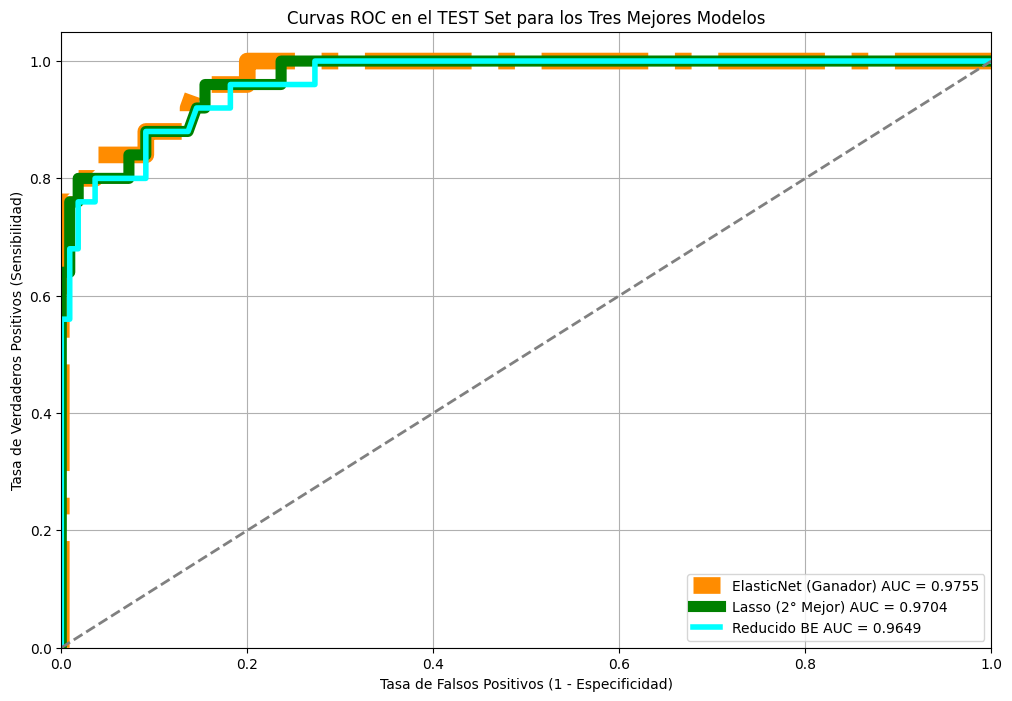

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import statsmodels.api as sm

# --- Get predictions for all models on the Test Set ---

# 1. Naive Bayes Model
y_test_pred_proba_nb = naive_bayes_model.predict_proba(X_test)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_test_pred_proba_nb)
auc_nb = auc(fpr_nb, tpr_nb)

# 2. Full Logistic Regression Model
X_test_const_full_lr = sm.add_constant(X_test)
y_test_pred_proba_full_lr = result.predict(X_test_const_full_lr)
fpr_full_lr, tpr_full_lr, _ = roc_curve(y_test, y_test_pred_proba_full_lr)
auc_full_lr = auc(fpr_full_lr, tpr_full_lr)

# 3. Reduced Logistic Regression Model (from Backward Elimination)
X_test_const_reduced_lr = sm.add_constant(X_test_reduced)
y_test_pred_proba_reduced_lr = result_reduced.predict(X_test_const_reduced_lr)
fpr_reduced_lr, tpr_reduced_lr, _ = roc_curve(y_test, y_test_pred_proba_reduced_lr)
auc_reduced_lr = auc(fpr_reduced_lr, tpr_reduced_lr)

# 4. Lasso Logistic Regression Model
y_test_pred_proba_lasso = best_lasso_model.predict_proba(X_test_reduced)[:, 1]
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_test_pred_proba_lasso)
auc_lasso = auc(fpr_lasso, tpr_lasso)

# 5. ElasticNet Logistic Regression Model
y_test_pred_proba_elasticnet = best_elasticnet_model.predict_proba(X_test_reduced)[:, 1]
fpr_elasticnet, tpr_elasticnet, _ = roc_curve(y_test, y_test_pred_proba_elasticnet)
auc_elasticnet = auc(fpr_elasticnet, tpr_elasticnet)

# --- Plot all ROC curves ---
plt.figure(figsize=(12, 8))

plt.plot(fpr_elasticnet, tpr_elasticnet, color='darkorange', lw=12, linestyle= "dashdot",
         label=f'ElasticNet (Ganador) AUC = {auc_elasticnet:.4f}')
plt.plot(fpr_lasso, tpr_lasso, color='green', lw=8,
         label=f'Lasso (2° Mejor) AUC = {auc_lasso:.4f}')
plt.plot(fpr_reduced_lr, tpr_reduced_lr, color='cyan', lw=4,
         label=f'Reducido BE AUC = {auc_reduced_lr:.4f}')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle= "dashed" )

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curvas ROC en el TEST Set para los Tres Mejores Modelos')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#900.Discusión de Implementación del Modelo ElasticNet para Niños Creativos  (Rúbrica i)

#ii.Resumen Ejecutivo-Gráficas AUC para mejor y segundo mejor modelo

**ADVERTENCIA: Favor para correr el modelo corra las celdas de código del RESUMEN EJECUTIVO de último ya que este requiere de correr previamente el modelo ElasticNet para hacer el gráfico.**

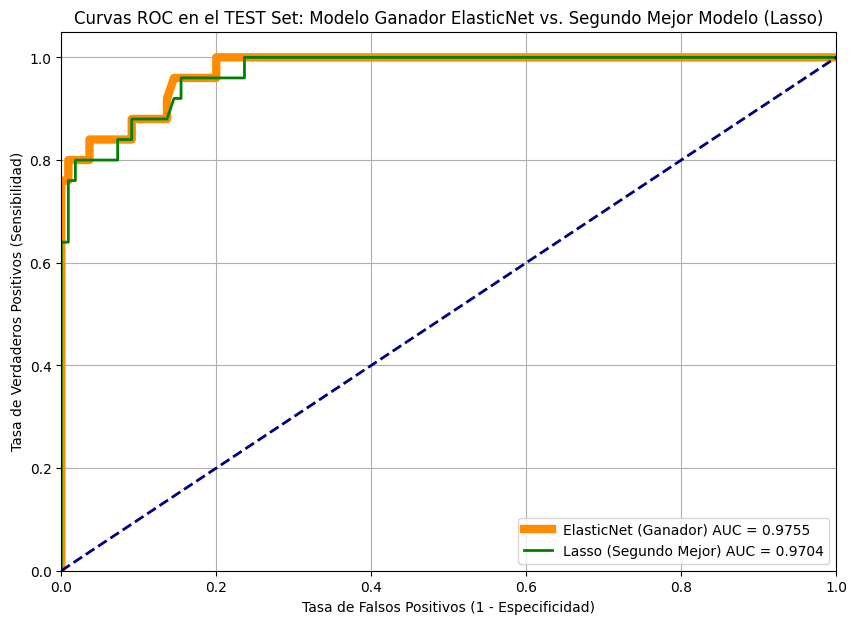

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- 1. Get predictions for the Winning ElasticNet Model (already available) ---
y_test_pred_proba_elasticnet = best_elasticnet_model.predict_proba(X_test_reduced)[:, 1]

# --- 2. Get predictions for the Second Best Model: Lasso Logistic Regression (already available) ---
y_test_pred_proba_lasso = best_lasso_model.predict_proba(X_test_reduced)[:, 1]

# --- 3. Calculate ROC curves and AUC for both models ---
fpr_elasticnet, tpr_elasticnet, _ = roc_curve(y_test, y_test_pred_proba_elasticnet)
auc_elasticnet = auc(fpr_elasticnet, tpr_elasticnet)

fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_test_pred_proba_lasso)
auc_lasso = auc(fpr_lasso, tpr_lasso)

# --- 4. Plot the ROC curves ---
plt.figure(figsize=(10, 7))
plt.plot(fpr_elasticnet, tpr_elasticnet, color='darkorange', lw=6,
         label=f'ElasticNet (Ganador) AUC = {auc_elasticnet:.4f}')
plt.plot(fpr_lasso, tpr_lasso, color='green', lw=2,
         label=f'Lasso (Segundo Mejor) AUC = {auc_lasso:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curvas ROC en el TEST Set: Modelo Ganador ElasticNet vs. Segundo Mejor Modelo (Lasso)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [32]:
# Retrieve the scaler object from the kernel state
# Assuming `scaler` object is available from cell `b20ccac2`
# If not, it would need to be re-instantiated and fitted on X_train's original numerical columns

# Find the index of 'Income' in the original numerical_cols used for scaling
numerical_cols = ['Income', 'ResLength'] # As defined when scaler was fitted
income_idx = numerical_cols.index('Income')

# Get mean and std for 'Income' from the fitted scaler
mean_income = scaler.mean_[income_idx]
std_income = scaler.scale_[income_idx]

# Get the intercept and coefficients of the winning ElasticNet model
original_intercept = best_elasticnet_model.intercept_[0]
original_coefficients = best_elasticnet_model.coef_[0]
features = X_train_reduced.columns.tolist()

# Find the index of 'Income' in the *reduced* features
income_feature_idx = features.index('Income')

# Original coefficient for standardized Income
coef_income_std = original_coefficients[income_feature_idx]

# Calculate the new coefficient for non-standardized Income
new_coef_income = coef_income_std / std_income

# Calculate the new intercept
new_intercept = original_intercept - (coef_income_std * mean_income / std_income)

# Create a list for the new coefficients (keeping others as they are)
new_coefficients = list(original_coefficients)
new_coefficients[income_feature_idx] = new_coef_income

# Reconstruct the formula string with non-standardized Income
formula_parts = [f"{new_intercept:.4f}"]

for i, feature in enumerate(features):
    if feature == 'Income':
        if new_coef_income >= 0:
            formula_parts.append(f" + ({new_coef_income:.7f} * {feature})") # Use 7 decimal places for Income for precision
        else:
            formula_parts.append(f" - ({abs(new_coef_income):.7f} * {feature})")
    else:
        coef = original_coefficients[i]
        if coef >= 0:
            formula_parts.append(f" + ({coef:.4f} * {feature})")
        else:
            formula_parts.append(f" - ({abs(coef):.4f} * {feature})")

log_odds_formula_descaled = " ".join(formula_parts)

print(f"Intercepto (beta_0 - desestandarizado para Income): {new_intercept:.4f}")
print("\nCoeficientes (beta_i - desestandarizado para Income) del modelo ganador ElasticNet:")
for i, feature in enumerate(features):
    if feature == 'Income':
        print(f"  {feature}: {new_coef_income:.7f}")
    else:
        print(f"  {feature}: {original_coefficients[i]:.4f}")

print("\nFórmula del modelo ganador ElasticNet (Log-Odds) con Income desestandarizado:")
print(f"log(p / (1-p)) = {log_odds_formula_descaled}")
print("\nDonde 'p' es la probabilidad de que el cliente compre la revista 'Niños Creativos'.")
print("Para obtener la probabilidad 'p' a partir de los log-odds, se usa la función sigmoide:")
print("p = 1 / (1 + exp(-log(p / (1-p))))")

Intercepto (beta_0 - desestandarizado para Income): -12.2996

Coeficientes (beta_i - desestandarizado para Income) del modelo ganador ElasticNet:
  Income: 0.0001480
  IsFemale: 1.1578
  IsRetired: -1.8450
  Minors: 0.7582
  Own: 1.0730
  PrevChild: 1.4605
  White: 1.6926

Fórmula del modelo ganador ElasticNet (Log-Odds) con Income desestandarizado:
log(p / (1-p)) = -12.2996  + (0.0001480 * Income)  + (1.1578 * IsFemale)  - (1.8450 * IsRetired)  + (0.7582 * Minors)  + (1.0730 * Own)  + (1.4605 * PrevChild)  + (1.6926 * White)

Donde 'p' es la probabilidad de que el cliente compre la revista 'Niños Creativos'.
Para obtener la probabilidad 'p' a partir de los log-odds, se usa la función sigmoide:
p = 1 / (1 + exp(-log(p / (1-p))))


##910.Uso de la Fórmula del Modelo Ganador en Marketing para 'Niños Creativos'

El modelo **ElasticNet Logistic Regression** que hemos seleccionado es una herramienta poderosa para NoExisto.com en su objetivo de decidir qué revistas comercializar para cada cliente. Aquí te explico cómo pueden hacer uso práctico de esta fórmula:

**1. Calcular la Probabilidad de Compra para 'Niños Creativos':**

Para cada cliente en su base de datos, NoExisto.com recopila los datos de las 7 características seleccionadas por nuestro modelo (`Income`, `IsFemale`, `IsRetired`, `Minors`, `Own`, `PrevChild`, `White`). Es crucial recordar que las variables `Income` deben ser estandarizadas utilizando el mismo `StandardScaler` que se ajustó durante la fase de entrenamiento del modelo.

Una vez que se tienen los valores estandarizados para un cliente, se introducen en la fórmula de Log-Odds:

`log(p / (1-p)) = Intercepto + (Coef_Income * Income_estandarizado) + ... + (Coef_White * White)`

Después de calcular los Log-Odds, se aplica la función sigmoide para obtener la probabilidad `p` (la probabilidad de que el cliente compre 'Niños Creativos'):

`p = 1 / (1 + exp(-log(p / (1-p))))`

Este `p` es la probabilidad estimada de que un cliente específico compre la revista 'Niños Creativos'.


**2. Personalización de la Campaña de Email Marketing:**

Si NoExisto.com desarrolla modelos similares para *todas* las revistas que vende, puede realizar el mismo cálculo de probabilidad `p` para cada cliente y para cada revista. Así, para un cliente dado, tendrán una lista de probabilidades de compra para todas las revistas disponibles.


**3. Selección de las Tres Revistas Principales:**

Con las probabilidades de compra calculadas para cada revista, NoExisto.com puede identificar las tres revistas para las cuales el cliente tiene la mayor probabilidad de compra. Estas tres revistas serían las que se incluirían en la parte superior del email de marketing personalizado enviado a ese cliente.


**4. Maximización de la Eficiencia y la Rentabilidad:**

Este enfoque permite a NoExisto.com pasar de una estrategia de marketing masiva a una **personalizada y basada en datos**. Al mostrar a cada cliente solo las revistas que tienen la *mayor probabilidad* de comprar, la empresa:

*   **Maximiza la tasa de conversión:** Es más probable que los clientes compren las revistas anunciadas.
*   **Optimiza el gasto en marketing:** Evita enviar anuncios irrelevantes, mejorando el retorno de la inversión.
*   **Mejora la experiencia del cliente:** Los clientes reciben contenido más pertinente a sus intereses, lo que puede fortalecer su relación con NoExisto.com.

En resumen, el modelo ganador no solo predice con alta precisión, sino que proporciona una estrategia clara y accionable para que NoExisto.com realice un marketing de revistas más inteligente y efectivo.

#-FIN DEL TRABAJO-FIN DEL TRABAJO--FIN DEL TRABAJO--FIN DEL TRABAJO-

#PARA PKL ARMAR EL ARCHIVO PKL

In [33]:
#PARA CREAR EL ARCHIVO.PKL
import pickle

# Guardamos el modelo entrenado en un archivo físico

with open('modelo.pkl', 'wb') as archivo_ninos_creativos:
  pickle.dump(best_elasticnet_model, archivo_ninos_creativos)

In [34]:
import numpy as np
import sklearn
print(f"NumPy: {np.__version__}")
print(f"Sklearn: {sklearn.__version__}")

NumPy: 2.0.2
Sklearn: 1.6.1


In [35]:
# DIAGNÓSTICO: ¿El modelo necesita Income estandarizado o raw?
import numpy as np

# Cliente de prueba con Income en valor REAL (raw)
cliente_raw = pd.DataFrame([{
    'Income': 45000,
    'IsFemale': 1,
    'IsRetired': 0,
    'Minors': 2,
    'Own': 1,
    'PrevChild': 1,
    'White': 0
}])

# Mismo cliente con Income ESTANDARIZADO usando el scaler del notebook
cliente_escalado = cliente_raw.copy()
cliente_escalado[['Income', 'ResLength']] = scaler.transform(
    pd.DataFrame([{'Income': 45000, 'ResLength': 17}])  # ResLength promedio ~17
)
# Eliminamos ResLength porque el modelo no la usa
cliente_escalado = cliente_escalado.drop(columns=['ResLength'], errors='ignore')

# Predicciones
pred_raw = best_elasticnet_model.predict(cliente_raw)
prob_raw = best_elasticnet_model.predict_proba(cliente_raw)[0]

pred_escalado = best_elasticnet_model.predict(cliente_escalado)
prob_escalado = best_elasticnet_model.predict_proba(cliente_escalado)[0]

print("=== CON INCOME RAW (45000) ===")
print(f"  Predicción: {pred_raw[0]}  |  Prob No compra: {prob_raw[0]:.4f}  |  Prob Compra: {prob_raw[1]:.4f}")

print("\n=== CON INCOME ESTANDARIZADO ===")
print(f"  Predicción: {pred_escalado[0]}  |  Prob No compra: {prob_escalado[0]:.4f}  |  Prob Compra: {prob_escalado[1]:.4f}")

print("\n=== VEREDICTO ===")
if pred_raw[0] != pred_escalado[0]:
    print("⚠️  LAS PREDICCIONES SON DISTINTAS → la API tiene un bug. Hay que corregirla.")
else:
    print(f"Las predicciones son iguales en clase, pero revisa las probabilidades.")
    if abs(prob_raw[1] - prob_escalado[1]) > 0.05:
        print("⚠️  Las probabilidades difieren más de 5% → igual hay que corregir la API.")
    else:
        print("✅  Todo consistente. La API puede recibir Income en valor raw.")

=== CON INCOME RAW (45000) ===
  Predicción: 1  |  Prob No compra: 0.0000  |  Prob Compra: 1.0000

=== CON INCOME ESTANDARIZADO ===
  Predicción: 0  |  Prob No compra: 0.6065  |  Prob Compra: 0.3935

=== VEREDICTO ===
⚠️  LAS PREDICCIONES SON DISTINTAS → la API tiene un bug. Hay que corregirla.


In [36]:
# SOLUCIÓN: Guardar modelo + scaler juntos en un pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pickle
import pandas as pd

# Volvemos a cargar los datos originales sin estandarizar
# (X_train_reduced tiene las 7 variables pero Income ya está escalado,
#  necesitamos rehacerlo desde el DataFrame limpio)

# Las 7 variables del modelo ganador
features_modelo = ['Income', 'IsFemale', 'IsRetired', 'Minors', 'Own', 'PrevChild', 'White']

# Reconstruir X_train y X_test SIN estandarizar (desde df_clean)
X_full = df_clean.drop(['ObsNo.', 'Buy'], axis=1)
y_full = df_clean['Buy']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_full, y_full, test_size=0.2, random_state=SEED_RANDOM_STATE, stratify=y_full
)

# Quedarnos solo con las 7 variables del modelo ganador
X_tr_7 = X_tr[features_modelo]
X_te_7 = X_te[features_modelo]

# Crear un Pipeline: primero escala Income, luego predice
# Usamos ColumnTransformer para escalar SOLO Income
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), ['Income'])
    ],
    remainder='passthrough'  # las otras 6 variables pasan sin cambio
)

pipeline_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_elasticnet_model)  # reutilizamos el modelo ya entrenado
])

# Ajustar el pipeline completo
pipeline_final.fit(X_tr_7, y_tr)

# Verificar que funciona correctamente
cliente_test = pd.DataFrame([{
    'Income': 45000,
    'IsFemale': 1,
    'IsRetired': 0,
    'Minors': 2,
    'Own': 1,
    'PrevChild': 1,
    'White': 0
}])

pred = pipeline_final.predict(cliente_test)
prob = pipeline_final.predict_proba(cliente_test)[0]
print(f"Predicción: {pred[0]}  |  Prob No compra: {prob[0]:.4f}  |  Prob Compra: {prob[1]:.4f}")
print("\nSi ves una probabilidad entre 0 y 1 (no exactamente 0.0000 ni 1.0000), el pipeline funciona bien ✅")

# Guardar el pipeline como nuevo modelo.pkl
with open('modelo.pkl', 'wb') as f:
    pickle.dump(pipeline_final, f)

print("\n✅ modelo.pkl guardado correctamente con scaler incluido")

Predicción: 0  |  Prob No compra: 0.6065  |  Prob Compra: 0.3935

Si ves una probabilidad entre 0 y 1 (no exactamente 0.0000 ni 1.0000), el pipeline funciona bien ✅

✅ modelo.pkl guardado correctamente con scaler incluido


In [37]:
from google.colab import files
files.download('modelo.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>